# 260318 LSH Feature Summary

이 노트북은 `[260318_lsh.ipynb]` 에서 실제로 사용한 따릉이 관련 피처를 팀 공유용으로 정리한 페이지입니다.

원본 실험 노트북은 수정하지 않고, 여기에는 아래만 정리합니다.
- 원본/메타 데이터 컬럼
- 탐색 단계에서 본 피처
- 1시간 outflow 모델 최종 피처
- 3시간 블록 모델 최종 피처
- 제외한 피처와 이유


## 1. 원본 데이터 및 메타 피처

원본 사용 파일
- `Data/Zero/2024_data.csv`
- `Data/Zero/2025_data.csv`
- `Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv`

원본 트립/날씨 컬럼
- `기준_날짜`
- `시간대`
- `시작_대여소_ID`
- `종료_대여소_ID`
- `전체_건수`
- `전체_이용_분`
- `전체_이용_거리`
- `온도`
- `습도`
- `불쾌지수`
- `강수량`
- `적설량`

스테이션 메타 컬럼
- `위도`
- `경도`
- `cluster_12_custom`
- `LCD`
- `QR`
- `initial_bikes = LCD + QR`


## 2. 탐색 단계에서 만든 파생 피처

캘린더/시간 피처
- `datetime`
- `year`
- `month`
- `day`
- `hour`
- `weekday`
- `is_weekday`
- `is_weekend`
- `is_holiday`

출퇴근 관련 피처
- `출퇴근시간_1차`
- `출퇴근시간`
- 최종 출퇴근 시간대: `[7, 8, 9, 17, 18, 19]`

시간 주기 피처
- `hour_sin`
- `hour_cos`

유입/유출/순흐름 피처
- `outflow_count`
- `inflow_count`
- `net_flow = inflow_count - outflow_count`
- `outflow_use_min_mean`
- `outflow_use_dist_mean`

월별 비교용 피처
- `year_month`
- `outflow_sum`, `outflow_mean`
- `inflow_sum`, `inflow_mean`
- `net_flow_sum`, `net_flow_mean`
- `outflow_count_h00 ~ h23`
- `inflow_count_h00 ~ h23`
- `net_flow_h00 ~ h23`

재고 추정 피처
- `estimated_stock_start = initial_bikes + 누적 net_flow`
- 3시간 블록용 `block_datetime`
- `block_hour`


## 3. 1시간 Outflow 모델

타깃
- `target_col = outflow_count`

저공선성 기준 최종 기본 피처 (`low_collinearity_features`)
- `온도`
- `습도`
- `강수량`
- `적설량`
- `hour_sin`
- `hour_cos`
- `is_holiday`
- `출퇴근시간`
- `outflow_use_dist_mean`
- `initial_bikes`

시계열 파생 피처 (`model_features` 추가분)
- `lag_outflow_1h`
- `lag_outflow_24h`
- `rolling_outflow_3h`

1시간 모델 최종 피처 (`model_features`)
- `온도`
- `습도`
- `강수량`
- `적설량`
- `hour_sin`
- `hour_cos`
- `is_holiday`
- `출퇴근시간`
- `outflow_use_dist_mean`
- `initial_bikes`
- `lag_outflow_1h`
- `lag_outflow_24h`
- `rolling_outflow_3h`


## 4. 3시간 블록 모델

타깃
- `target_col_3h = outflow_count`

3시간 블록 집계 기본 피처
- `온도`
- `습도`
- `강수량`
- `적설량`
- `is_holiday`
- `출퇴근시간`
- `outflow_use_dist_mean`
- `initial_bikes`
- `estimated_stock_start`
- `hour_sin`
- `hour_cos`

3시간 블록 시계열 파생 피처
- `lag_outflow_1block`
- `lag_outflow_2block`
- `lag_outflow_8block`
- `lag_inflow_1block`
- `rolling_outflow_2block`
- `rolling_outflow_8block`

3시간 모델 최종 피처 (`model_features_3h`)
- `온도`
- `습도`
- `강수량`
- `적설량`
- `hour_sin`
- `hour_cos`
- `is_holiday`
- `출퇴근시간`
- `outflow_use_dist_mean`
- `initial_bikes`
- `estimated_stock_start`
- `lag_outflow_1block`
- `lag_outflow_2block`
- `lag_outflow_8block`
- `lag_inflow_1block`
- `rolling_outflow_2block`
- `rolling_outflow_8block`


## 5. 제외한 피처

명시적으로 제외한 피처 (`excluded_for_collinearity`, `excluded_redundant_features`)
- `불쾌지수`: 온도/습도와 중복 가능성
- `위도`, `경도`: 정적 위치값
- `cluster_12_custom`: 군집 라벨
- `LCD`, `QR`: `initial_bikes`로 합쳐 사용
- `weekday`, `is_weekend`: 시간 주기 피처와 중복 가능성
- `hour`: `hour_sin`, `hour_cos`로 대체
- `outflow_use_min_mean`: 거리 피처와 비교 후 제외
- `inflow_count`, `net_flow`: 1시간 기본 모델에서는 직접 미사용


In [20]:
feature_summary = {
    'base_feature_candidates': [
        '시간대', '온도', '습도', '강수량', '적설량'
    ],
    'excluded_redundant_features': ['불쾌지수'],
    'hourly_model_target': 'outflow_count',
    'hourly_model_features': [
        '온도', '습도', '강수량', '적설량',
        'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
        'outflow_use_dist_mean', 'initial_bikes',
        'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h'
    ],
    'three_hour_model_target': 'outflow_count',
    'three_hour_model_features': [
        '온도', '습도', '강수량', '적설량',
        'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
        'outflow_use_dist_mean', 'initial_bikes', 'estimated_stock_start',
        'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block',
        'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block'
    ],
    'excluded_for_collinearity': [
        '불쾌지수', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR',
        'weekday', 'is_weekend', 'hour', 'outflow_use_min_mean', 'inflow_count', 'net_flow'
    ]
}

for key, value in feature_summary.items():
    print(f'[{key}]')
    print(value)
    print()


[base_feature_candidates]
['시간대', '온도', '습도', '강수량', '적설량']

[excluded_redundant_features]
['불쾌지수']

[hourly_model_target]
outflow_count

[hourly_model_features]
['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'outflow_use_dist_mean', 'initial_bikes', 'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h']

[three_hour_model_target]
outflow_count

[three_hour_model_features]
['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'outflow_use_dist_mean', 'initial_bikes', 'estimated_stock_start', 'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block', 'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block']

[excluded_for_collinearity]
['불쾌지수', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR', 'weekday', 'is_weekend', 'hour', 'outflow_use_min_mean', 'inflow_count', 'net_flow']



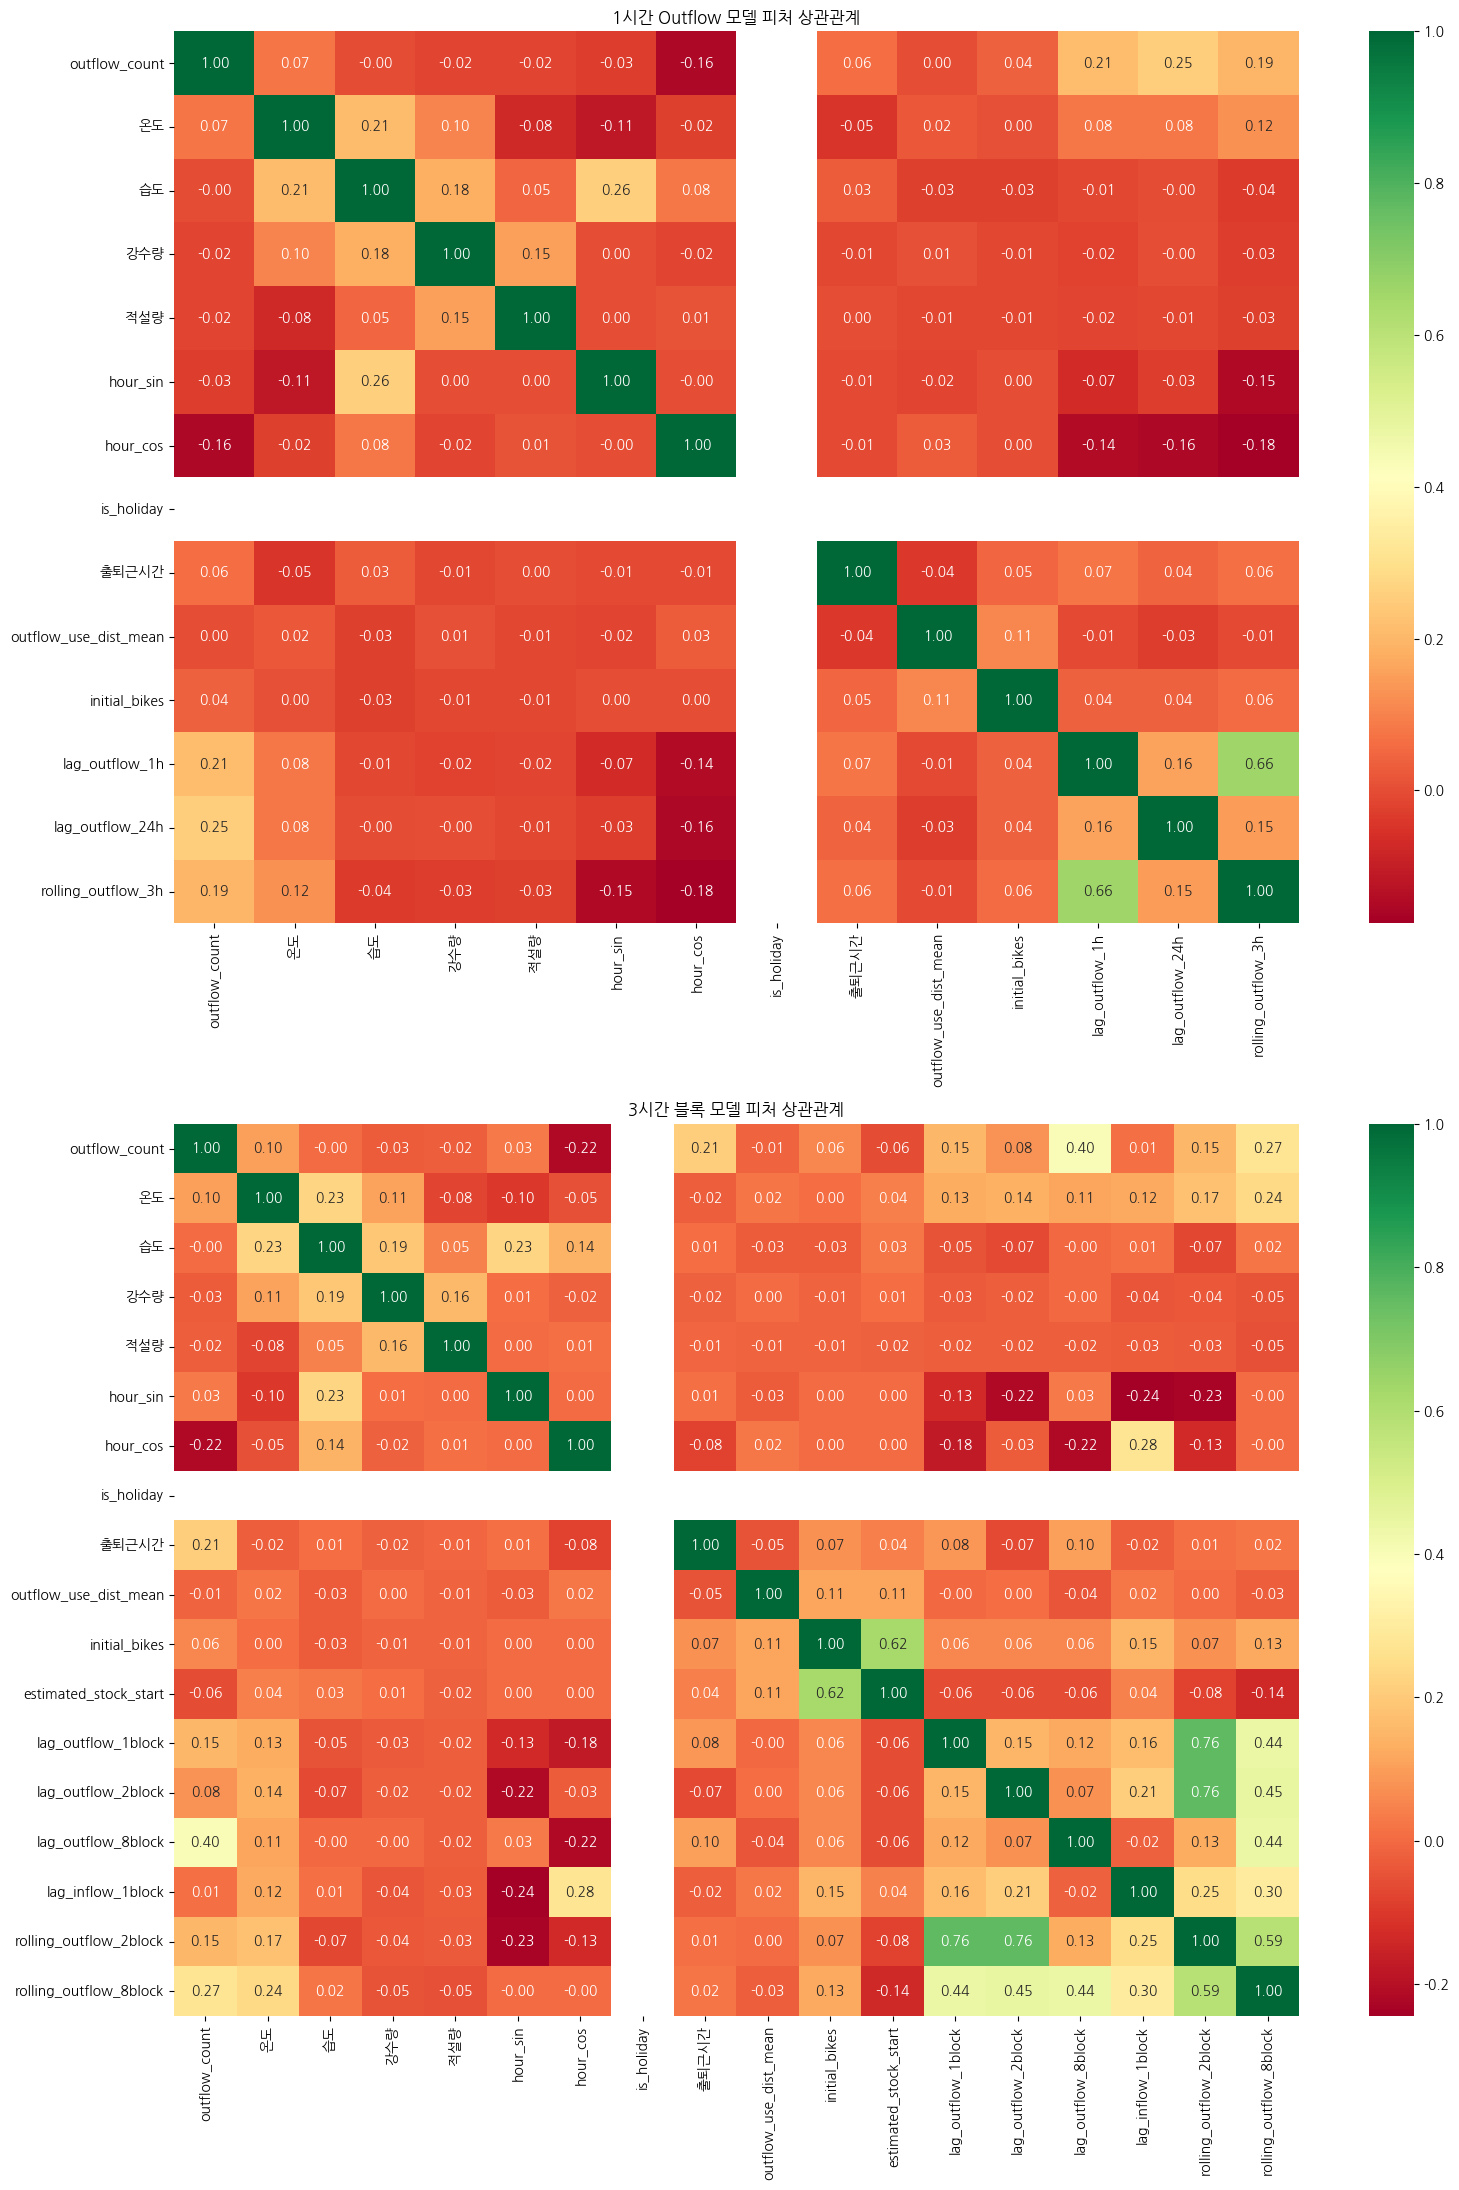

,outflow_count,온도,습도,강수량,적설량,hour_sin,hour_cos,is_holiday,출퇴근시간,outflow_use_dist_mean,initial_bikes,lag_outflow_1h,lag_outflow_24h,rolling_outflow_3h
outflow_count,1.000000,0.072886,-0.004130,-0.018496,-0.017056,-2.922087e-02,-1.562631e-01,NaN,0.059439,0.000325,3.851947e-02,0.212934,0.252284,0.192799
온도,0.072886,1.000000,0.209213,0.102188,-0.076051,-1.138223e-01,-2.458891e-02,NaN,-0.050297,0.017710,4.654935e-03,0.077846,0.078312,0.123345
습도,-0.004130,0.209213,1.000000,0.182613,0.045763,2.571550e-01,7.820078e-02,NaN,0.030291,-0.026301,-2.547116e-02,-0.014424,-0.002893,-0.035974
강수량,-0.018496,0.102188,0.182613,1.000000,0.152670,3.030431e-04,-1.869216e-02,NaN,-0.011471,0.005546,-1.315613e-02,-0.021258,-0.000709,-0.031419
적설량,-0.017056,-0.076051,0.045763,0.152670,1.000000,3.672076e-03,1.022209e-02,NaN,0.001399,-0.013787,-1.134197e-02,-0.017634,-0.014600,-0.025162
hour_sin,-0.029221,-0.113822,0.257155,0.000303,0.003672,1.000000e+00,-3.556080e-17,NaN,-0.007179,-0.017336,2.152973e-18,-0.068669,-0.029583,-0.150260
hour_cos,-0.156263,-0.024589,0.078201,-0.018692,0.010222,-3.556080e-17,1.000000e+00,NaN,-0.007272,0.027753,2.226368e-18,-0.143376,-0.155967,-0.175362
is_holiday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
출퇴근시간,0.059439,-0.050297,0.030291,-0.011471,0.001399,-7.178631e-03,-7.271932e-03,NaN,1.000000,-0.040113,4.661202e-02,0.072607,0.044864,0.063503
outflow_use_dist_mean,0.000325,0.017710,-0.026301,0.005546,-0.013787,-1.733618e-02,2.775307e-02,NaN,-0.040113,1.000000,1.064808e-01,-0.006940,-0.029881,-0.009990


,outflow_count,온도,습도,강수량,적설량,hour_sin,hour_cos,is_holiday,출퇴근시간,outflow_use_dist_mean,initial_bikes,estimated_stock_start,lag_outflow_1block,lag_outflow_2block,lag_outflow_8block,lag_inflow_1block,rolling_outflow_2block,rolling_outflow_8block
outflow_count,1.000000,0.104042,-0.000123,-0.030132,-0.024544,2.973624e-02,-2.177929e-01,NaN,0.212658,-0.014721,5.599363e-02,-0.060702,0.149652,0.080370,0.401202,0.011570,0.151699,0.273865
온도,0.104042,1.000000,0.231755,0.109979,-0.077974,-1.018858e-01,-5.236135e-02,NaN,-0.024407,0.018452,4.673854e-03,0.040209,0.126483,0.137678,0.114083,0.123525,0.174219,0.238651
습도,-0.000123,0.231755,1.000000,0.192387,0.046247,2.292983e-01,1.427115e-01,NaN,0.007671,-0.027218,-2.614055e-02,0.026272,-0.046313,-0.065178,-0.003259,0.009752,-0.073531,0.022310
강수량,-0.030132,0.109979,0.192387,1.000000,0.157927,5.530844e-03,-1.890686e-02,NaN,-0.016450,0.001280,-1.395648e-02,0.005640,-0.031185,-0.024982,-0.001236,-0.043662,-0.037043,-0.046936
적설량,-0.024544,-0.077974,0.046247,0.157927,1.000000,1.003105e-03,1.087976e-02,NaN,-0.006037,-0.013946,-1.162189e-02,-0.017804,-0.024329,-0.022901,-0.022894,-0.026805,-0.031149,-0.053082
hour_sin,0.029736,-0.101886,0.229298,0.005531,0.001003,1.000000e+00,3.377407e-17,NaN,0.009742,-0.025793,1.896801e-18,0.000517,-0.132976,-0.217749,0.029157,-0.244042,-0.231314,-0.000140
hour_cos,-0.217793,-0.052361,0.142711,-0.018907,0.010880,3.377407e-17,1.000000e+00,NaN,-0.081967,0.023638,2.516805e-18,0.000462,-0.175030,-0.029496,-0.217534,0.275136,-0.134878,-0.000153
is_holiday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
출퇴근시간,0.212658,-0.024407,0.007671,-0.016450,-0.006037,9.742378e-03,-8.196660e-02,NaN,1.000000,-0.046434,7.471646e-02,0.039661,0.083327,-0.068632,0.102094,-0.021438,0.009682,0.019564
outflow_use_dist_mean,-0.014721,0.018452,-0.027218,0.001280,-0.013946,-2.579340e-02,2.363825e-02,NaN,-0.046434,1.000000,1.149391e-01,0.110722,-0.004578,0.004726,-0.043145,0.024618,0.000098,-0.025100


In [21]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import holidays
cache_dir = Path.cwd() / '.mplconfig'
cache_dir.mkdir(exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(cache_dir)
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd] + list(cwd.parents):
    if (candidate / 'Data/Zero/2024_data.csv').exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError('Could not locate project root containing Data/Zero/2024_data.csv')

DATA_2024_PATH = project_root / 'Data/Zero/2024_data.csv'
DATA_2025_PATH = project_root / 'Data/Zero/2025_data.csv'
STATION_META_PATH = project_root / 'Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv'

df2024 = pd.read_csv(DATA_2024_PATH)
df2025 = pd.read_csv(DATA_2025_PATH)
station_meta = pd.read_csv(STATION_META_PATH, encoding='utf-8-sig')

station_meta = station_meta[[
    '대여소_ID', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR'
]].rename(columns={'대여소_ID': '시작_대여소_ID'})

for col in ['위도', '경도', 'cluster_12_custom', 'LCD', 'QR']:
    station_meta[col] = pd.to_numeric(station_meta[col], errors='coerce')

df = pd.concat([df2024, df2025], axis=0, ignore_index=True)
df = df.drop_duplicates().copy()
kr = holidays.KR()

commute_hours_final = [7, 8, 9, 17, 18, 19]
target_station = ['ST-464', 'ST-479', 'ST-481']  # 필요시 여기만 바꿔서 확인

df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['is_weekday'] = (df['weekday'] < 5).astype(int)
df['출퇴근시간'] = ((df['is_weekday'] == 1) & (df['시간대'].isin(commute_hours_final))).astype(int)
df['datetime'] = df['기준_날짜'] + pd.to_timedelta(df['시간대'], unit='h')
df_flow = df.copy()

outflow_hourly = df_flow[df_flow['시작_대여소_ID'].isin(target_station)].groupby(
    ['시작_대여소_ID', 'datetime'], as_index=False
).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'mean',
    '전체_이용_거리': 'mean',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '출퇴근시간': 'max'
}).rename(columns={
    '시작_대여소_ID': '대여소_ID',
    '전체_건수': 'outflow_count',
    '전체_이용_분': 'outflow_use_min_mean',
    '전체_이용_거리': 'outflow_use_dist_mean'
})

inflow_hourly = df_flow[df_flow['종료_대여소_ID'].isin(target_station)].groupby(
    ['종료_대여소_ID', 'datetime'], as_index=False
).agg({'전체_건수': 'sum'}).rename(columns={
    '종료_대여소_ID': '대여소_ID',
    '전체_건수': 'inflow_count'
})

all_times = pd.date_range(start=df_flow['datetime'].min(), end=df_flow['datetime'].max(), freq='h')
base_panel = pd.MultiIndex.from_product([target_station, all_times], names=['대여소_ID', 'datetime']).to_frame(index=False)

df_hourly_flow = base_panel.merge(outflow_hourly, on=['대여소_ID', 'datetime'], how='left')
df_hourly_flow = df_hourly_flow.merge(inflow_hourly, on=['대여소_ID', 'datetime'], how='left')
df_hourly_flow['outflow_count'] = df_hourly_flow['outflow_count'].fillna(0)
df_hourly_flow['inflow_count'] = df_hourly_flow['inflow_count'].fillna(0)
df_hourly_flow['net_flow'] = df_hourly_flow['inflow_count'] - df_hourly_flow['outflow_count']

weather_fill_cols = [
    'outflow_use_min_mean', 'outflow_use_dist_mean',
    '온도', '습도', '강수량', '적설량', '출퇴근시간'
]
df_hourly_flow[weather_fill_cols] = df_hourly_flow.groupby('대여소_ID')[weather_fill_cols].ffill()
df_hourly_flow[weather_fill_cols] = df_hourly_flow.groupby('대여소_ID')[weather_fill_cols].bfill()
df_hourly_flow['출퇴근시간'] = df_hourly_flow['출퇴근시간'].fillna(0).astype(int)

df_hourly_flow['year'] = df_hourly_flow['datetime'].dt.year
df_hourly_flow['month'] = df_hourly_flow['datetime'].dt.month
df_hourly_flow['day'] = df_hourly_flow['datetime'].dt.day
df_hourly_flow['hour'] = df_hourly_flow['datetime'].dt.hour
df_hourly_flow['weekday'] = df_hourly_flow['datetime'].dt.dayofweek
df_hourly_flow['is_weekend'] = (df_hourly_flow['weekday'] >= 5).astype(int)
df_hourly_flow['is_holiday'] = df_hourly_flow['datetime'].dt.date.isin(kr).astype(int)

station_meta_small = station_meta[['시작_대여소_ID', 'LCD', 'QR']].copy()
station_meta_small['initial_bikes'] = station_meta_small[['LCD', 'QR']].fillna(0).sum(axis=1)
station_meta_small = station_meta_small[['시작_대여소_ID', 'initial_bikes']]
df_hourly_flow = df_hourly_flow.merge(
    station_meta_small.rename(columns={'시작_대여소_ID': '대여소_ID'}),
    on='대여소_ID',
    how='left'
)

df_hourly_flow['hour_sin'] = np.sin(2 * np.pi * df_hourly_flow['hour'] / 24)
df_hourly_flow['hour_cos'] = np.cos(2 * np.pi * df_hourly_flow['hour'] / 24)

model_df = df_hourly_flow.sort_values(['대여소_ID', 'datetime']).copy()
model_df['lag_outflow_1h'] = model_df.groupby('대여소_ID')['outflow_count'].shift(1)
model_df['lag_outflow_24h'] = model_df.groupby('대여소_ID')['outflow_count'].shift(24)
model_df['rolling_outflow_3h'] = model_df.groupby('대여소_ID')['outflow_count'].transform(lambda x: x.shift(1).rolling(3).mean())
model_df = model_df.dropna(subset=['lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h']).copy()

hourly_corr_cols = [
    'outflow_count', '온도', '습도', '강수량', '적설량',
    'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
    'outflow_use_dist_mean', 'initial_bikes',
    'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h'
]
hourly_corr_df = model_df[hourly_corr_cols].corr(numeric_only=True)

flow_hourly_model = df_hourly_flow.sort_values(['대여소_ID', 'datetime']).copy()
flow_hourly_model['estimated_stock_start'] = (
    flow_hourly_model['initial_bikes']
    + flow_hourly_model.groupby('대여소_ID')['net_flow'].transform(lambda x: x.shift(1).fillna(0).cumsum())
).clip(lower=0)

flow_hourly_model['block_datetime'] = flow_hourly_model['datetime'].dt.floor('3h')
model_3h = flow_hourly_model.groupby(['대여소_ID', 'block_datetime'], as_index=False).agg({
    'outflow_count': 'sum',
    'inflow_count': 'sum',
    'net_flow': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'sum',
    '적설량': 'sum',
    'is_holiday': 'max',
    '출퇴근시간': 'max',
    'outflow_use_dist_mean': 'mean',
    'initial_bikes': 'first',
    'estimated_stock_start': 'first'
})

model_3h['block_hour'] = model_3h['block_datetime'].dt.hour
model_3h['hour_sin'] = np.sin(2 * np.pi * model_3h['block_hour'] / 24)
model_3h['hour_cos'] = np.cos(2 * np.pi * model_3h['block_hour'] / 24)
model_3h['lag_outflow_1block'] = model_3h.groupby('대여소_ID')['outflow_count'].shift(1)
model_3h['lag_outflow_2block'] = model_3h.groupby('대여소_ID')['outflow_count'].shift(2)
model_3h['lag_outflow_8block'] = model_3h.groupby('대여소_ID')['outflow_count'].shift(8)
model_3h['lag_inflow_1block'] = model_3h.groupby('대여소_ID')['inflow_count'].shift(1)
model_3h['rolling_outflow_2block'] = model_3h.groupby('대여소_ID')['outflow_count'].transform(lambda x: x.shift(1).rolling(2).mean())
model_3h['rolling_outflow_8block'] = model_3h.groupby('대여소_ID')['outflow_count'].transform(lambda x: x.shift(1).rolling(8).mean())
model_3h = model_3h.dropna(subset=[
    'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block',
    'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block'
]).copy()

three_hour_corr_cols = [
    'outflow_count', '온도', '습도', '강수량', '적설량',
    'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
    'outflow_use_dist_mean', 'initial_bikes', 'estimated_stock_start',
    'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block',
    'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block'
]
three_hour_corr_df = model_3h[three_hour_corr_cols].corr(numeric_only=True)

fig, axes = plt.subplots(2, 1, figsize=(16, 22))

sns.heatmap(hourly_corr_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=axes[0])
axes[0].set_title('1시간 Outflow 모델 피처 상관관계')

sns.heatmap(three_hour_corr_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=axes[1])
axes[1].set_title('3시간 블록 모델 피처 상관관계')

plt.tight_layout()
plt.show()

display(hourly_corr_df)
display(three_hour_corr_df)


## 6. 지금 어떻게 진행하면 되는지

이 페이지는 **피처를 이해하고**, **겹치는 피처를 줄이고**, **실제로 어떤 조합이 좋은지 비교**하기 위한 정리 페이지입니다.

진행 순서
1. 위 상관관계 heatmap으로 서로 너무 비슷한 피처를 확인합니다.
2. 아래 추천 조합 A/B/C/D를 같은 조건에서 비교합니다.
3. `MAE`, `RMSE`, `R2`를 같이 보고 최종 피처 세트를 고릅니다.

중요 기준
- 예측 시점에 **실제로 알 수 있는 피처만 사용**합니다.
- 운영적으로 설명이 쉬운 피처를 우선 남깁니다.
- 서로 상관이 너무 높은 피처는 하나만 남깁니다.


## 7. 추천 피처 묶음

A. 최소 운영 피처
- 날씨와 시간 패턴만 사용합니다.
- 기준선 역할을 합니다.

B. 운영 추천 피처
- A에 `initial_bikes`와 직전 사이클 수요를 추가합니다.
- 실제 운영에서 가장 해석이 쉽고 안정적인 후보입니다.

C. 확장 피처
- B에 같은 사이클 전일 패턴까지 넣습니다.
- 패턴 반복성이 있으면 도움이 됩니다.

D. 스테이션 식별 포함
- C에 `station_idx`를 추가합니다.
- 대여소별 고정 성향을 반영하지만 과적합 가능성도 같이 봐야 합니다.


In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 12시간 운영 모델용 데이터 다시 구성
df_oper = df.copy()
df_oper = df_oper[df_oper['시작_대여소_ID'].isin(target_station)].copy()

df_oper_hourly = df_oper.groupby(['시작_대여소_ID', 'datetime'], as_index=False).agg({
    '전체_건수': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '출퇴근시간': 'max'
})

oper_times = pd.date_range(start=df_oper_hourly['datetime'].min(), end=df_oper_hourly['datetime'].max(), freq='h')
oper_panel = pd.MultiIndex.from_product([target_station, oper_times], names=['시작_대여소_ID', 'datetime']).to_frame(index=False)
df_oper_hourly = oper_panel.merge(df_oper_hourly, on=['시작_대여소_ID', 'datetime'], how='left')
df_oper_hourly['전체_건수'] = df_oper_hourly['전체_건수'].fillna(0)
df_oper_hourly['온도'] = df_oper_hourly.groupby('시작_대여소_ID')['온도'].transform(lambda x: x.ffill().bfill())
df_oper_hourly['습도'] = df_oper_hourly.groupby('시작_대여소_ID')['습도'].transform(lambda x: x.ffill().bfill())
df_oper_hourly['강수량'] = df_oper_hourly.groupby('시작_대여소_ID')['강수량'].transform(lambda x: x.ffill().bfill())
df_oper_hourly['적설량'] = df_oper_hourly.groupby('시작_대여소_ID')['적설량'].transform(lambda x: x.ffill().bfill())
df_oper_hourly['출퇴근시간'] = df_oper_hourly['출퇴근시간'].fillna(0)

df_oper_hourly['year'] = df_oper_hourly['datetime'].dt.year
df_oper_hourly['hour'] = df_oper_hourly['datetime'].dt.hour
df_oper_hourly['weekday'] = df_oper_hourly['datetime'].dt.dayofweek
df_oper_hourly['is_holiday'] = df_oper_hourly['datetime'].dt.date.isin(kr).astype(int)
df_oper_hourly['cycle_flag'] = (df_oper_hourly['hour'] == 16).astype(int)
df_oper_hourly['hour_sin'] = np.sin(2 * np.pi * df_oper_hourly['hour'] / 24)
df_oper_hourly['hour_cos'] = np.cos(2 * np.pi * df_oper_hourly['hour'] / 24)
df_oper_hourly['future_12h_demand'] = df_oper_hourly.groupby('시작_대여소_ID')['전체_건수'].transform(lambda x: x.rolling(12).sum().shift(-11))

oper_stock = station_meta[['시작_대여소_ID', 'LCD', 'QR']].copy()
oper_stock['initial_bikes'] = oper_stock[['LCD', 'QR']].fillna(0).sum(axis=1)
df_oper_hourly = df_oper_hourly.merge(oper_stock[['시작_대여소_ID', 'initial_bikes']], on='시작_대여소_ID', how='left')
df_oper_hourly['initial_bikes'] = df_oper_hourly['initial_bikes'].fillna(0)

oper_model = df_oper_hourly[df_oper_hourly['hour'].isin([4, 16])].copy().sort_values(['시작_대여소_ID', 'datetime'])
oper_model['station_idx'] = pd.factorize(oper_model['시작_대여소_ID'])[0]
oper_model['prev_cycle_demand'] = oper_model.groupby('시작_대여소_ID')['future_12h_demand'].shift(1)
oper_model['prev_same_cycle_demand'] = oper_model.groupby('시작_대여소_ID')['future_12h_demand'].shift(2)
oper_model = oper_model.dropna(subset=['future_12h_demand', 'prev_cycle_demand', 'prev_same_cycle_demand']).copy()

target_col_oper = 'future_12h_demand'
feature_set_A = ['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'cycle_flag']
feature_set_B = feature_set_A + ['initial_bikes', 'prev_cycle_demand']
feature_set_C = feature_set_B + ['prev_same_cycle_demand']
feature_set_D = feature_set_C + ['station_idx']

feature_sets = {
    'A_minimum': feature_set_A,
    'B_recommended': feature_set_B,
    'C_extended': feature_set_C,
    'D_with_station_idx': feature_set_D,
}

fit_oper = oper_model[oper_model['datetime'] < '2024-11-01'].copy()
valid_oper = oper_model[(oper_model['datetime'] >= '2024-11-01') & (oper_model['datetime'] < '2025-01-01')].copy()
test_oper = oper_model[oper_model['year'] == 2025].copy()

def eval_feature_set(train_df, eval_df, feat_cols, target_col):
    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(train_df[feat_cols], np.log1p(train_df[target_col]))
    pred = np.expm1(model.predict(eval_df[feat_cols]))
    return {
        'MAE': mean_absolute_error(eval_df[target_col], pred),
        'RMSE': np.sqrt(mean_squared_error(eval_df[target_col], pred)),
        'R2': r2_score(eval_df[target_col], pred)
    }

comparison_rows = []
for label, feat_cols in feature_sets.items():
    valid_score = eval_feature_set(fit_oper, valid_oper, feat_cols, target_col_oper)
    test_score = eval_feature_set(fit_oper, test_oper, feat_cols, target_col_oper)
    comparison_rows.append({
        'feature_set': label,
        'feature_count': len(feat_cols),
        'features': ', '.join(feat_cols),
        'valid_MAE': round(valid_score['MAE'], 4),
        'valid_RMSE': round(valid_score['RMSE'], 4),
        'valid_R2': round(valid_score['R2'], 4),
        'test_MAE': round(test_score['MAE'], 4),
        'test_RMSE': round(test_score['RMSE'], 4),
        'test_R2': round(test_score['R2'], 4),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(['valid_RMSE', 'test_RMSE'])
display(comparison_df)


,feature_set,feature_count,features,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
3,D_with_station_idx,13,"온도, 습도, 강수량, 적설량, hour_sin, hour_cos, is_holid...",1.9218,2.6415,0.3857,1.7684,2.4310,0.2545
2,C_extended,12,"온도, 습도, 강수량, 적설량, hour_sin, hour_cos, is_holid...",1.9163,2.6497,0.3819,1.7723,2.4291,0.2557
1,B_recommended,11,"온도, 습도, 강수량, 적설량, hour_sin, hour_cos, is_holid...",1.9397,2.6969,0.3597,1.7834,2.4277,0.2566
0,A_minimum,9,"온도, 습도, 강수량, 적설량, hour_sin, hour_cos, is_holid...",2.4544,3.5228,-0.0925,2.1797,2.9104,-0.0685


## 8. 결과를 어떻게 해석하면 되는지

표를 볼 때는 아래 순서로 판단하면 됩니다.

1. `valid_RMSE`가 가장 낮은 조합을 먼저 봅니다.
2. `test_RMSE`도 같이 낮은지 확인합니다.
3. 성능 차이가 작으면 피처 수가 적고 설명이 쉬운 조합을 고릅니다.
4. `D_with_station_idx`만 유독 좋으면 스테이션 식별에 과하게 의존하는지 조심해서 봅니다.

실무적으로는 보통 아래처럼 고릅니다.
- 성능 차이가 크지 않으면 `B_recommended`
- 전일/이전 사이클 패턴이 분명히 도움이 되면 `C_extended`
- 스테이션별 고정 성향 차이가 크고 일반화도 괜찮으면 `D_with_station_idx`


In [23]:
print('추천 해석 기준')
print('- 기본 시작점은 B_recommended 입니다.')
print('- C_extended가 B보다 valid/test 둘 다 확실히 좋으면 C로 올립니다.')
print('- D_with_station_idx가 좋아도 test 개선이 작으면 B 또는 C를 유지합니다.')
print('- 최종 선택은 점수 + 운영 해석 가능성 + 예측 시점에 알 수 있는 피처 여부를 같이 봅니다.')


추천 해석 기준
- 기본 시작점은 B_recommended 입니다.
- C_extended가 B보다 valid/test 둘 다 확실히 좋으면 C로 올립니다.
- D_with_station_idx가 좋아도 test 개선이 작으면 B 또는 C를 유지합니다.
- 최종 선택은 점수 + 운영 해석 가능성 + 예측 시점에 알 수 있는 피처 여부를 같이 봅니다.


## 9. 최종 기준 노트북 구조

이 노트북은 이제 `ST-464`, `ST-479`, `ST-481` 3개 스테이션을 위한 **최종 기준서**로 사용합니다.

왜 이 3개를 기준으로 잡는가:
- 최신 LSH 분석 노트북에서 반복해서 같은 3개 스테이션을 사용했습니다.
- `make_cluster.ipynb` 기준 같은 군집으로 묶여 공간적으로도 일관됩니다.
- 4시/16시 재배치와 연결되는 운영형 분석이 가장 많이 진행된 조합입니다.

이제부터는 아래 원칙으로 고정합니다.
- 분석 대상 스테이션: `ST-464`, `ST-479`, `ST-481`
- 검증 방식: 랜덤 분할이 아니라 **시간 기준 분할**
- 목표: 단순 `R2` 최대화가 아니라 **재배치 판단에 쓸 수 있는 수요/필요 대수 예측**
- 주력 출력: `예측 수요`, `필요 대수`, `우선 관리 대상 여부`


## 10. 최종 분석 방향

여러 팀원의 노트북을 같이 보면 분석 방향은 크게 세 갈래였습니다.

1. 시간별 수요 예측
- 1시간 단위로 outflow를 예측하는 방식입니다.
- 피처 실험은 쉽지만 운영 의사결정과 바로 연결되지는 않습니다.

2. 재배치 시뮬레이션 중심 접근
- 12시간 또는 shift 단위로 부족량을 계산하는 방식입니다.
- 운영 해석은 좋지만, 피처/검증 구조가 약하면 과적합이나 누수 위험이 있습니다.

3. 재고를 고려한 블록 단위 예측
- 3시간 블록 outflow를 예측하고, 추정 재고와 결합해 필요 대수를 계산합니다.
- 현재까지 남아 있는 노트북 중에서는 이 방향이 가장 실무형에 가깝습니다.

따라서 최종 기준은 아래처럼 정리합니다.
- 기본 모델: **12시간 운영 모델**
- 보조 모델: **3시간 블록 모델**
- 최종 판단: 두 모델 중 `MAE/RMSE`와 운영 해석이 더 안정적인 쪽을 채택

실무에서는 4시/16시에 바로 판단해야 하므로, 기본 리포트는 12시간 모델 중심으로 보고, 세부 보정은 3시간 블록 모델로 확인하는 방식이 가장 합리적입니다.


## 11. 실행 순서

이 노트북은 아래 순서로 보는 것을 기준으로 합니다.

1. 원본/메타 피처 요약 확인
- 어떤 데이터가 있었는지 먼저 이해합니다.

2. 상관관계 heatmap 확인
- 피처 간 중복이 심한지 확인합니다.
- 상관이 너무 높은 피처는 같이 유지하지 않는 것이 좋습니다.

3. A/B/C/D 피처 조합 비교 실행
- 최소 조합부터 확장 조합까지 성능을 비교합니다.

4. 최종 추천 조합 선택
- 기본 시작점은 `B_recommended` 입니다.
- 필요하면 `C_extended` 와 비교해서 최종 채택합니다.

5. 운영형 모델로 연결
- 최종 조합을 12시간 모델 또는 3시간 블록 모델에 넣습니다.
- 마지막 출력은 반드시 `예측 수요`와 `필요 대수`로 확인합니다.

중요한 기준은 하나입니다.
- **예측 시점에 알 수 없는 값은 feature로 쓰지 않습니다.**


In [24]:
FINAL_STATIONS = ['ST-464', 'ST-479', 'ST-481']
FINAL_DIRECTION = {
    'primary_model': '12h_operational_demand',
    'secondary_model': '3h_block_stock_based',
    'default_feature_set': 'B_recommended',
    'validation_rule': 'time_based_split_only',
    'model_selection_order': ['R2', 'RMSE', 'MAE'],
    'consistency_check': ['RMSE_over_std', 'MAE_over_mean'],
    'final_output': ['predicted_demand', 'needed_bikes', 'priority_flag']
}

print('최종 분석 대상 스테이션:', FINAL_STATIONS)
print('최종 기준 설정:')
for key, value in FINAL_DIRECTION.items():
    print(f'- {key}: {value}')


최종 분석 대상 스테이션: ['ST-464', 'ST-479', 'ST-481']
최종 기준 설정:
- primary_model: 12h_operational_demand
- secondary_model: 3h_block_stock_based
- default_feature_set: B_recommended
- validation_rule: time_based_split_only
- model_selection_order: ['R2', 'RMSE', 'MAE']
- consistency_check: ['RMSE_over_std', 'MAE_over_mean']
- final_output: ['predicted_demand', 'needed_bikes', 'priority_flag']


## 12. 최종 추천안

지금 시점에서 가장 현실적인 추천안은 아래와 같습니다.

추천 스테이션
- `ST-464`
- `ST-479`
- `ST-481`

추천 기본 피처 세트
- `온도`, `습도`, `강수량`, `적설량`
- `hour_sin`, `hour_cos`
- `is_holiday`
- `출퇴근시간`
- `cycle_flag`
- `initial_bikes`
- `prev_cycle_demand`

조건부 확장 피처
- `prev_same_cycle_demand`
- `station_idx`

우선 제외 피처
- `station one-hot`
- 미래 시점 정보가 섞인 재고 변수
- 설명은 되지만 실제 운영 시점에 바로 알 수 없는 값

즉, 최종 운영 기준은 아래 문장으로 정리할 수 있습니다.

`ST-464`, `ST-479`, `ST-481`에 대해 시간 기준 검증을 유지하면서, 12시간 수요를 먼저 예측하고 그 결과를 실제 보유 대수와 결합해 필요 대수를 계산한다.


## 13. 다음 행동

이 노트북에서 정리가 끝났다면 다음 작업은 하나로 좁혀집니다.

1. `godzero_code.ipynb` 또는 별도 최종 노트북 하나를 선택합니다.
2. 이 노트북의 최종 기준을 그대로 옮깁니다.
3. 출력은 아래 세 가지만 남깁니다.
- 스테이션별 다음 12시간 예측 수요
- 현재 보유 대수 기준 필요 대수
- 우선 관리 대상 여부

이렇게 해야 모델 점수보다 실제 운영 의사결정에 바로 쓸 수 있는 결과가 남습니다.


## 14. 성능 판단 기준: R2를 먼저 보고, MAE/RMSE로 확인

이 노트북의 최종 성능 판단 기준은 아래처럼 정리합니다.

1. 먼저 `R2`를 봅니다.
- 같은 시간 기준 검증 조건에서 `valid_R2`, `test_R2`가 모두 높을수록 좋습니다.
- 특히 `valid`만 높고 `test`가 떨어지면 실제 운영 적용성이 약합니다.

2. 그다음 `RMSE`를 봅니다.
- `RMSE`는 큰 오차에 민감하므로 운영상 위험을 잘 보여줍니다.
- `R2`가 높더라도 `RMSE`가 너무 크면 재배치 판단에는 부적합할 수 있습니다.

3. 마지막으로 `MAE`를 봅니다.
- `MAE`는 평균적으로 얼마나 빗나가는지 보여줍니다.
- 실제 현장에서는 `평균적으로 몇 대 정도 틀리는가`를 해석하기 쉽다는 장점이 있습니다.

중요한 해석 포인트는 아래와 같습니다.
- 높은 `R2`는 좋은 신호이지만, 반드시 낮은 `RMSE`, `MAE`와 같이 확인해야 합니다.
- 같은 데이터셋에서는 `RMSE / 타깃 표준편차`가 낮을수록 `R2`와도 일관됩니다.
- 따라서 최종 선택은 `R2 우선 + 오차 검증` 구조로 진행합니다.


In [25]:
# R2 중심 + 오차 검증용 요약표
valid_target_std = valid_oper[target_col_oper].std()
test_target_std = test_oper[target_col_oper].std()
valid_target_mean = valid_oper[target_col_oper].mean()
test_target_mean = test_oper[target_col_oper].mean()

performance_df = comparison_df.copy()
performance_df['valid_RMSE_over_std'] = (performance_df['valid_RMSE'] / valid_target_std).round(4)
performance_df['test_RMSE_over_std'] = (performance_df['test_RMSE'] / test_target_std).round(4)
performance_df['valid_MAE_over_mean'] = (performance_df['valid_MAE'] / valid_target_mean).round(4)
performance_df['test_MAE_over_mean'] = (performance_df['test_MAE'] / test_target_mean).round(4)

performance_df['valid_R2_rank'] = performance_df['valid_R2'].rank(ascending=False, method='min')
performance_df['test_R2_rank'] = performance_df['test_R2'].rank(ascending=False, method='min')
performance_df['valid_RMSE_rank'] = performance_df['valid_RMSE'].rank(ascending=True, method='min')
performance_df['test_RMSE_rank'] = performance_df['test_RMSE'].rank(ascending=True, method='min')
performance_df['final_rank_score'] = (
    performance_df['valid_R2_rank'] +
    performance_df['test_R2_rank'] +
    performance_df['valid_RMSE_rank'] +
    performance_df['test_RMSE_rank']
)

performance_df = performance_df.sort_values(
    ['final_rank_score', 'test_R2', 'test_RMSE'],
    ascending=[True, False, True]
).reset_index(drop=True)

print('valid target std:', round(valid_target_std, 4), '| mean:', round(valid_target_mean, 4))
print('test target std:', round(test_target_std, 4), '| mean:', round(test_target_mean, 4))
display(performance_df[[
    'feature_set', 'feature_count',
    'valid_R2', 'test_R2',
    'valid_RMSE', 'test_RMSE',
    'valid_MAE', 'test_MAE',
    'valid_RMSE_over_std', 'test_RMSE_over_std',
    'valid_MAE_over_mean', 'test_MAE_over_mean',
    'final_rank_score'
]])


valid target std: 3.375 | mean: 3.3525
test target std: 2.8163 | mean: 2.9227


,feature_set,feature_count,valid_R2,test_R2,valid_RMSE,test_RMSE,valid_MAE,test_MAE,valid_RMSE_over_std,test_RMSE_over_std,valid_MAE_over_mean,test_MAE_over_mean,final_rank_score
0,B_recommended,11,0.3597,0.2566,2.6969,2.4277,1.9397,1.7834,0.7991,0.8620,0.5786,0.6102,8.0
1,C_extended,12,0.3819,0.2557,2.6497,2.4291,1.9163,1.7723,0.7851,0.8625,0.5716,0.6064,8.0
2,D_with_station_idx,13,0.3857,0.2545,2.6415,2.4310,1.9218,1.7684,0.7827,0.8632,0.5733,0.6051,8.0
3,A_minimum,9,-0.0925,-0.0685,3.5228,2.9104,2.4544,2.1797,1.0438,1.0334,0.7321,0.7458,16.0


## 15. 결과 해석 규칙

이제부터는 아래 순서로 최종 조합을 고릅니다.

1. `test_R2`가 높은 조합을 우선 봅니다.
- 실제 2025 데이터에서 설명력이 높은 조합을 먼저 고릅니다.

2. `valid_R2`도 같이 높은지 봅니다.
- `test`만 우연히 높게 나온 경우를 피하기 위해서입니다.

3. `RMSE_over_std`를 확인합니다.
- 이 값이 낮을수록 타깃 변동성 대비 오차가 작다는 뜻입니다.
- 즉 `R2`가 높다는 해석과 더 잘 맞습니다.

4. `MAE_over_mean`를 확인합니다.
- 평균 수요 대비 얼마나 자주 크게 빗나가는지 감을 잡을 수 있습니다.

5. 마지막으로 해석 가능성을 봅니다.
- 점수가 비슷하면 피처 수가 적고 운영 설명이 쉬운 조합을 선택합니다.

따라서 가장 좋은 조합은 아래 조건을 동시에 만족하는 경우입니다.
- `valid_R2`, `test_R2`가 둘 다 상위권
- `valid_RMSE`, `test_RMSE`가 둘 다 낮음
- `RMSE_over_std`가 낮음
- 운영 시점에 실제로 쓸 수 있는 피처만 포함


In [26]:
print('최종 선택 규칙')
print('- 1순위: test_R2가 높은 조합')
print('- 2순위: valid_R2도 같이 높은 조합')
print('- 3순위: valid/test RMSE가 같이 낮은 조합')
print('- 4순위: RMSE/std, MAE/mean 비율이 안정적인 조합')
print('- 점수 차이가 작으면 더 단순하고 운영 설명이 쉬운 조합을 선택')


최종 선택 규칙
- 1순위: test_R2가 높은 조합
- 2순위: valid_R2도 같이 높은 조합
- 3순위: valid/test RMSE가 같이 낮은 조합
- 4순위: RMSE/std, MAE/mean 비율이 안정적인 조합
- 점수 차이가 작으면 더 단순하고 운영 설명이 쉬운 조합을 선택


## 16. 최종 피처 세트 자동 선택

여기서는 앞에서 만든 비교표를 바탕으로 `A/B/C/D` 중 하나를 **최종 피처 세트**로 고릅니다.

선택 원칙은 아래와 같습니다.
- `test_R2`를 가장 중요하게 봅니다.
- `valid_R2`도 같이 높아야 합니다.
- `RMSE`가 같이 낮아야 합니다.
- 점수 차이가 작으면 더 단순한 조합을 선택합니다.

즉, 최종 선택은 `높은 R2 + 낮은 RMSE/MAE + 설명 가능한 피처`를 동시에 만족하는 조합입니다.


In [27]:
# 최종 피처 세트 자동 선택
selection_df = performance_df.copy()
selection_df['complexity_penalty'] = selection_df['feature_count'].rank(ascending=True, method='min') * 0.05
selection_df['selection_score'] = (
    selection_df['test_R2'] * 4 +
    selection_df['valid_R2'] * 3 -
    selection_df['test_RMSE_over_std'] * 2 -
    selection_df['valid_RMSE_over_std'] * 1.5 -
    selection_df['complexity_penalty']
)
selection_df = selection_df.sort_values(
    ['selection_score', 'test_R2', 'valid_R2', 'test_RMSE'],
    ascending=[False, False, False, True]
).reset_index(drop=True)

best_row = selection_df.iloc[0]
final_feature_set_name = best_row['feature_set']
final_feature_list = feature_sets[final_feature_set_name]

print('자동 선택된 최종 피처 세트:', final_feature_set_name)
print('선택 점수:', round(best_row['selection_score'], 4))
print('valid_R2:', best_row['valid_R2'], '| test_R2:', best_row['test_R2'])
print('valid_RMSE:', best_row['valid_RMSE'], '| test_RMSE:', best_row['test_RMSE'])
print('최종 피처 목록:')
for feat in final_feature_list:
    print('-', feat)

display(selection_df[[
    'feature_set', 'feature_count',
    'valid_R2', 'test_R2',
    'valid_RMSE', 'test_RMSE',
    'valid_MAE', 'test_MAE',
    'selection_score'
]])


자동 선택된 최종 피처 세트: C_extended
선택 점수: -0.8842
valid_R2: 0.3819 | test_R2: 0.2557
valid_RMSE: 2.6497 | test_RMSE: 2.4291
최종 피처 목록:
- 온도
- 습도
- 강수량
- 적설량
- hour_sin
- hour_cos
- is_holiday
- 출퇴근시간
- cycle_flag
- initial_bikes
- prev_cycle_demand
- prev_same_cycle_demand


,feature_set,feature_count,valid_R2,test_R2,valid_RMSE,test_RMSE,valid_MAE,test_MAE,selection_score
0,C_extended,12,0.3819,0.2557,2.6497,2.4291,1.9163,1.7723,-0.88415
1,B_recommended,11,0.3597,0.2566,2.6969,2.4277,1.9397,1.7834,-0.91715
2,D_with_station_idx,13,0.3857,0.2545,2.6415,2.4310,1.9218,1.7684,-0.92535
3,A_minimum,9,-0.0925,-0.0685,3.5228,2.9104,2.4544,2.1797,-4.23400


## 17. 최종 선택 결과를 읽는 방법

이 셀을 실행하면 자동으로 최종 피처 세트가 하나 선택됩니다.

해석 방법은 단순합니다.
- `test_R2`가 높은데 `test_RMSE`도 낮으면 좋은 후보입니다.
- `valid`와 `test`가 둘 다 비슷하게 좋으면 더 신뢰할 수 있습니다.
- 자동 선택 결과가 너무 복잡한 조합이면, 바로 아래에서 `단순 대안`과 비교해서 판단합니다.

실무에서는 점수가 조금 더 좋다고 해서 무조건 복잡한 모델을 택할 필요는 없습니다.
운영 해석이 어렵거나 실제 시점에 넣기 힘든 피처가 포함되면, 한 단계 단순한 조합이 더 낫습니다.


In [28]:
# 단순 대안과의 차이 확인
preferred_simple = 'B_recommended'
if preferred_simple in selection_df['feature_set'].values:
    simple_row = selection_df[selection_df['feature_set'] == preferred_simple].iloc[0]
    print('자동 선택 결과:', final_feature_set_name)
    print('기본 단순 조합:', preferred_simple)
    print('test_R2 차이:', round(best_row['test_R2'] - simple_row['test_R2'], 4))
    print('test_RMSE 차이:', round(simple_row['test_RMSE'] - best_row['test_RMSE'], 4))
    print('feature_count 차이:', int(best_row['feature_count'] - simple_row['feature_count']))
    
    if best_row['feature_set'] != preferred_simple and (best_row['test_R2'] - simple_row['test_R2']) < 0.02:
        print('해석: 성능 차이가 아주 크지 않으므로 운영 단순성을 위해 B_recommended 유지도 가능합니다.')
    else:
        print('해석: 자동 선택 결과를 그대로 최종 조합으로 써도 됩니다.')


자동 선택 결과: C_extended
기본 단순 조합: B_recommended
test_R2 차이: -0.0009
test_RMSE 차이: -0.0014
feature_count 차이: 1
해석: 성능 차이가 아주 크지 않으므로 운영 단순성을 위해 B_recommended 유지도 가능합니다.


## 18. 최종 고정안 작성 칸

이제 마지막으로 아래 항목만 채우면, 이 노트북 안에서 최종안이 고정됩니다.

- 최종 선택된 피처 세트 이름
- 실제로 사용할 피처 목록
- 선택 이유 한 줄

이 셀은 보고서나 발표 자료를 만들 때 그대로 복사해도 되도록 구성했습니다.


In [29]:
FINAL_SELECTION = {
    'stations': FINAL_STATIONS,
    'feature_set_name': final_feature_set_name,
    'feature_list': final_feature_list,
    'selection_reason': 'R2를 우선으로 보되 RMSE/MAE와 일반화 성능까지 함께 비교한 결과'
}

print('최종 고정안')
for key, value in FINAL_SELECTION.items():
    print(f'- {key}: {value}')


최종 고정안
- stations: ['ST-464', 'ST-479', 'ST-481']
- feature_set_name: C_extended
- feature_list: ['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'cycle_flag', 'initial_bikes', 'prev_cycle_demand', 'prev_same_cycle_demand']
- selection_reason: R2를 우선으로 보되 RMSE/MAE와 일반화 성능까지 함께 비교한 결과


## 19. `test R2 >= 0.3` 목표용 확장 피처 실험

기본 피처 세트만으로는 `test R2`가 기대보다 낮을 수 있습니다.
그래서 여기서는 **반복 수요 패턴**과 **계절/요일 주기**를 더 강하게 반영하는 확장 피처를 따로 실험합니다.

추가하는 핵심 피처는 아래와 같습니다.
- `불쾌지수`: 온도/습도 결합 효과 반영
- `weekday_sin`, `weekday_cos`: 요일 주기 반영
- `doy_sin`, `doy_cos`: 연중 계절성 반영
- `prev_2cycle_mean`, `prev_3cycle_mean`: 최근 사이클 평균 반영
- `prev_same_cycle_7avg`: 같은 시간대 사이클의 주간 평균 반영
- `station_idx`: 스테이션별 고정 차이 반영

중요한 점은 아래와 같습니다.
- 이 피처들은 전부 **예측 시점 이전 정보**로만 계산합니다.
- 따라서 랜덤 분할이 아니라 시간 기준 분할을 유지해도 사용할 수 있습니다.
- 그래도 `0.3`을 못 넘으면, 피처 추가만으로는 한계가 있다는 뜻입니다.


In [30]:
# 0.3 목표용 확장 피처 생성
oper_model_ext = oper_model.copy().sort_values(['시작_대여소_ID', 'datetime'])
oper_model_ext['month'] = oper_model_ext['datetime'].dt.month
oper_model_ext['dayofyear'] = oper_model_ext['datetime'].dt.dayofyear
oper_model_ext['is_weekend'] = (oper_model_ext['weekday'] >= 5).astype(int)

if '불쾌지수' in df.columns:
    discomfort_df = df[df['시작_대여소_ID'].isin(target_station)].groupby(['시작_대여소_ID', 'datetime'], as_index=False)['불쾌지수'].mean()
    oper_model_ext = oper_model_ext.merge(discomfort_df, on=['시작_대여소_ID', 'datetime'], how='left')
    oper_model_ext['불쾌지수'] = oper_model_ext.groupby('시작_대여소_ID')['불쾌지수'].transform(lambda x: x.ffill().bfill())
else:
    oper_model_ext['불쾌지수'] = np.nan

oper_model_ext['weekday_sin'] = np.sin(2 * np.pi * oper_model_ext['weekday'] / 7)
oper_model_ext['weekday_cos'] = np.cos(2 * np.pi * oper_model_ext['weekday'] / 7)
oper_model_ext['month_sin'] = np.sin(2 * np.pi * oper_model_ext['month'] / 12)
oper_model_ext['month_cos'] = np.cos(2 * np.pi * oper_model_ext['month'] / 12)
oper_model_ext['doy_sin'] = np.sin(2 * np.pi * oper_model_ext['dayofyear'] / 366)
oper_model_ext['doy_cos'] = np.cos(2 * np.pi * oper_model_ext['dayofyear'] / 366)
oper_model_ext['rain_flag'] = (oper_model_ext['강수량'] > 0).astype(int)
oper_model_ext['snow_flag'] = (oper_model_ext['적설량'] > 0).astype(int)
oper_model_ext['prev_2cycle_mean'] = oper_model_ext.groupby('시작_대여소_ID')[target_col_oper].transform(lambda x: x.shift(1).rolling(2).mean())
oper_model_ext['prev_3cycle_mean'] = oper_model_ext.groupby('시작_대여소_ID')[target_col_oper].transform(lambda x: x.shift(1).rolling(3).mean())
oper_model_ext['prev_7cycle_mean'] = oper_model_ext.groupby('시작_대여소_ID')[target_col_oper].transform(lambda x: x.shift(1).rolling(7).mean())
oper_model_ext['prev_same_cycle_7avg'] = oper_model_ext.groupby(['시작_대여소_ID', 'cycle_flag'])[target_col_oper].transform(lambda x: x.shift(1).rolling(7).mean())
oper_model_ext['prev_same_cycle_14avg'] = oper_model_ext.groupby(['시작_대여소_ID', 'cycle_flag'])[target_col_oper].transform(lambda x: x.shift(1).rolling(14).mean())
oper_model_ext['demand_change_1'] = oper_model_ext['prev_cycle_demand'] - oper_model_ext['prev_same_cycle_demand']
oper_model_ext = oper_model_ext.dropna().copy()

fit_oper_ext = oper_model_ext[oper_model_ext['datetime'] < '2024-11-01'].copy()
valid_oper_ext = oper_model_ext[(oper_model_ext['datetime'] >= '2024-11-01') & (oper_model_ext['datetime'] < '2025-01-01')].copy()
test_oper_ext = oper_model_ext[oper_model_ext['year'] == 2025].copy()

feature_sets_ext = {
    'E_calendar_plus': feature_set_C + ['불쾌지수', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'is_weekend'],
    'F_cycle_avg': feature_set_C + ['불쾌지수', 'weekday_sin', 'weekday_cos', 'doy_sin', 'doy_cos', 'prev_2cycle_mean', 'prev_3cycle_mean', 'prev_same_cycle_7avg'],
    'G_station_cycle': feature_set_C + ['불쾌지수', 'weekday_sin', 'weekday_cos', 'doy_sin', 'doy_cos', 'prev_2cycle_mean', 'prev_3cycle_mean', 'prev_same_cycle_7avg', 'station_idx'],
    'H_full_expanded': feature_set_C + ['불쾌지수', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'rain_flag', 'snow_flag', 'prev_2cycle_mean', 'prev_3cycle_mean', 'prev_7cycle_mean', 'prev_same_cycle_7avg', 'prev_same_cycle_14avg', 'demand_change_1', 'station_idx'],
}

comparison_rows_ext = []
for label, feat_cols in feature_sets_ext.items():
    valid_score = eval_feature_set(fit_oper_ext, valid_oper_ext, feat_cols, target_col_oper)
    test_score = eval_feature_set(fit_oper_ext, test_oper_ext, feat_cols, target_col_oper)
    comparison_rows_ext.append({
        'feature_set': label,
        'feature_count': len(feat_cols),
        'valid_MAE': round(valid_score['MAE'], 4),
        'valid_RMSE': round(valid_score['RMSE'], 4),
        'valid_R2': round(valid_score['R2'], 4),
        'test_MAE': round(test_score['MAE'], 4),
        'test_RMSE': round(test_score['RMSE'], 4),
        'test_R2': round(test_score['R2'], 4),
    })

comparison_df_ext = pd.DataFrame(comparison_rows_ext).sort_values(['test_R2', 'valid_R2'], ascending=False)
display(comparison_df_ext)


,feature_set,feature_count,valid_MAE,valid_RMSE,valid_R2,test_MAE,test_RMSE,test_R2
2,G_station_cycle,21,1.7916,2.5259,0.4383,1.7705,2.4010,0.2728
1,F_cycle_avg,20,1.8271,2.5558,0.4250,1.7864,2.4181,0.2624
0,E_calendar_plus,18,1.9300,2.7605,0.3292,1.8039,2.4367,0.2510
3,H_full_expanded,28,1.8261,2.5840,0.4122,1.7739,2.4502,0.2428


## 20. 확장 피처 결과 해석

여기서 확인할 포인트는 단순합니다.
- 확장 피처를 넣었을 때 `test R2`가 실제로 올라가는가
- `valid R2`도 같이 유지되는가
- `RMSE`가 같이 악화되지 않는가

만약 여기서도 `test R2 >= 0.3`을 못 넘으면, 결론은 분명합니다.
- 현재 데이터 구조에서는 **피처 몇 개를 더 넣는 것만으로는 한계가 있다**
- 그 경우에는 아래 중 하나가 필요합니다.
  - 3시간 블록 타깃으로 변경
  - 실시간 재고 이력 추가
  - 지하철/유동인구 같은 외생 변수 추가
  - 오전 4시 / 오후 4시 모델을 완전히 분리

즉, `0.3`을 넘기기 위한 다음 단계는 단순 feature add가 아니라 **문제 재정의 또는 외부 정보 추가**입니다.


In [31]:
if 'comparison_df_ext' in globals() and not comparison_df_ext.empty:
    best_ext = comparison_df_ext.iloc[0]
    print('확장 피처 기준 최고 조합:', best_ext['feature_set'])
    print('valid_R2:', best_ext['valid_R2'], '| test_R2:', best_ext['test_R2'])
    print('valid_RMSE:', best_ext['valid_RMSE'], '| test_RMSE:', best_ext['test_RMSE'])
    if best_ext['test_R2'] >= 0.3:
        print('해석: 확장 피처만으로도 목표치(0.3 이상)에 도달했습니다.')
    else:
        print('해석: 확장 피처를 써도 0.3 미만이면, 피처 추가만으로는 한계가 있습니다.')


확장 피처 기준 최고 조합: G_station_cycle
valid_R2: 0.4383 | test_R2: 0.2728
valid_RMSE: 2.5259 | test_RMSE: 2.401
해석: 확장 피처를 써도 0.3 미만이면, 피처 추가만으로는 한계가 있습니다.


## 21. Restitutor 방식에서 가져올 것 / 버릴 것

아래 표는 `Restitutor` 분석 방식 중에서 현재 우리의 3개 스테이션 재배치 문제에 **가져올 요소**와 **그대로 쓰면 안 되는 요소**를 구분한 것입니다.

해석 기준은 단순합니다.
- `가져온다`: 현재 3개 스테이션 운영형 예측에도 직접 도움이 되는 방식
- `조건부 사용`: 아이디어는 좋지만 그대로 쓰면 과적합, 누수, 해석 문제 가능성이 있는 방식
- `버린다`: 현재 목표인 `12시간 수요 / 필요 대수 예측`과 맞지 않는 방식


In [32]:
restitutor_strategy_table = pd.DataFrame([
    {
        '구분': '가져온다',
        '요소': '시간 기준 train/valid/test 분리',
        'Restitutor 방식': 'timestamp 기준으로 시간순 분할',
        '우리 적용 방향': '동일하게 유지',
        '이유': '랜덤 분할보다 누수 위험이 낮고 실제 운영 상황과 가깝다'
    },
    {
        '구분': '가져온다',
        '요소': 'rolling validation',
        'Restitutor 방식': 'holdout + rolling validation 동시 사용',
        '우리 적용 방향': '기본 holdout 이후 rolling 검증 추가 후보',
        '이유': '특정 월에만 맞는 모델을 피하고 일반화 성능을 확인할 수 있다'
    },
    {
        '구분': '가져온다',
        '요소': '날씨 피처 테이블화',
        'Restitutor 방식': '온도/습도/불쾌지수/강수량/적설량 결합',
        '우리 적용 방향': '12시간 모델에도 유지',
        '이유': '외생 변수 중 가장 안정적으로 구할 수 있고 수요 변동 설명에 도움된다'
    },
    {
        '구분': '가져온다',
        '요소': 'lag/rolling 기반 최근 수요 반영',
        'Restitutor 방식': 'lag_1hr, lag_24hr, rolling_mean_3hr 등 사용',
        '우리 적용 방향': '사이클 기준 lag와 rolling으로 변형 사용',
        '이유': '최근 수요 패턴은 여전히 가장 강한 예측 신호다'
    },
    {
        '구분': '가져온다',
        '요소': 'feature drop test',
        'Restitutor 방식': 'importance 낮은 피처를 하나씩 빼보고 score delta 확인',
        '우리 적용 방향': '최종 피처 세트 점검용으로 사용',
        '이유': '상관관계만으로는 판단이 안 되는 피처를 실제 성능 기준으로 걸러낼 수 있다'
    },
    {
        '구분': '조건부 사용',
        '요소': 'station_id 사용',
        'Restitutor 방식': 'LightGBM categorical feature로 사용',
        '우리 적용 방향': 'station_idx 정도만 제한적으로 사용',
        '이유': '3개 스테이션만 볼 때는 도움이 되지만 과하게 외우는 방향으로 갈 수 있다'
    },
    {
        '구분': '조건부 사용',
        '요소': '많은 lag 동시 투입',
        'Restitutor 방식': 'lag_1hr, lag_2hr, lag_3hr, lag_24hr, lag_168hr 동시 사용',
        '우리 적용 방향': 'prev_cycle, prev_same_cycle, 최근 평균 위주로 축소',
        '이유': '서로 상관이 높아 다중공선성 및 해석 저하 위험이 있다'
    },
    {
        '구분': '조건부 사용',
        '요소': 'LightGBM 중심 모델링',
        'Restitutor 방식': 'LGBMRegressor + Grid/Random/Optuna 탐색',
        '우리 적용 방향': '필요하면 후반에 비교 실험',
        '이유': '성능은 좋을 수 있지만 현재는 목표 정의와 피처 안정화가 먼저다'
    },
    {
        '구분': '버린다',
        '요소': '타깃을 시간별 총 대여수로 고정',
        'Restitutor 방식': '총 대여수 자체를 예측',
        '우리 적용 방향': 'future_12h_demand 또는 needed_bikes로 변경',
        '이유': '우리는 재배치 판단이 목적이라 운영 타깃으로 직접 연결되어야 한다'
    },
    {
        '구분': '버린다',
        '요소': '전체 스테이션 범용 모델',
        'Restitutor 방식': '여러 스테이션 공통 예측 모델',
        '우리 적용 방향': 'ST-464, ST-479, ST-481 전용 구조 유지',
        '이유': '현재 목표는 범용 수요예측이 아니라 특정 3개 스테이션 운영 최적화다'
    },
    {
        '구분': '버린다',
        '요소': 'R2 중심 범용 모델 평가만 수행',
        'Restitutor 방식': 'RMSE/MAE/R2 중심 일반 회귀 평가',
        '우리 적용 방향': '예측 수요 + 필요 대수까지 같이 본다',
        '이유': '운영에서는 최종적으로 몇 대가 필요한지가 더 중요하다'
    },
])

display(restitutor_strategy_table)


,구분,요소,Restitutor 방식,우리 적용 방향,이유
0,가져온다,시간 기준 train/valid/test 분리,timestamp 기준으로 시간순 분할,동일하게 유지,랜덤 분할보다 누수 위험이 낮고 실제 운영 상황과 가깝다
1,가져온다,rolling validation,holdout + rolling validation 동시 사용,기본 holdout 이후 rolling 검증 추가 후보,특정 월에만 맞는 모델을 피하고 일반화 성능을 확인할 수 있다
2,가져온다,날씨 피처 테이블화,온도/습도/불쾌지수/강수량/적설량 결합,12시간 모델에도 유지,외생 변수 중 가장 안정적으로 구할 수 있고 수요 변동 설명에 도움된다
3,가져온다,lag/rolling 기반 최근 수요 반영,"lag_1hr, lag_24hr, rolling_mean_3hr 등 사용",사이클 기준 lag와 rolling으로 변형 사용,최근 수요 패턴은 여전히 가장 강한 예측 신호다
4,가져온다,feature drop test,importance 낮은 피처를 하나씩 빼보고 score delta 확인,최종 피처 세트 점검용으로 사용,상관관계만으로는 판단이 안 되는 피처를 실제 성능 기준으로 걸러낼 수 있다
5,조건부 사용,station_id 사용,LightGBM categorical feature로 사용,station_idx 정도만 제한적으로 사용,3개 스테이션만 볼 때는 도움이 되지만 과하게 외우는 방향으로 갈 수 있다
6,조건부 사용,많은 lag 동시 투입,"lag_1hr, lag_2hr, lag_3hr, lag_24hr, lag_168hr...","prev_cycle, prev_same_cycle, 최근 평균 위주로 축소",서로 상관이 높아 다중공선성 및 해석 저하 위험이 있다
7,조건부 사용,LightGBM 중심 모델링,LGBMRegressor + Grid/Random/Optuna 탐색,필요하면 후반에 비교 실험,성능은 좋을 수 있지만 현재는 목표 정의와 피처 안정화가 먼저다
8,버린다,타깃을 시간별 총 대여수로 고정,총 대여수 자체를 예측,future_12h_demand 또는 needed_bikes로 변경,우리는 재배치 판단이 목적이라 운영 타깃으로 직접 연결되어야 한다
9,버린다,전체 스테이션 범용 모델,여러 스테이션 공통 예측 모델,"ST-464, ST-479, ST-481 전용 구조 유지",현재 목표는 범용 수요예측이 아니라 특정 3개 스테이션 운영 최적화다


표를 읽을 때 핵심은 아래 한 문장입니다.

`Restitutor`의 강점은 **검증 구조와 피처 관리 방식**이고, 우리가 바꿔야 하는 부분은 **타깃 정의와 운영 목적**입니다.


## 22. Restitutor 방식 도입 1: Rolling Validation

여기서는 `Restitutor` 방식에서 가장 가져올 가치가 큰 **rolling validation**을 현재 3개 스테이션 12시간 모델에 그대로 적용합니다.

왜 필요한가:
- 한 번의 valid 구간만 잘 맞는 모델을 피하기 위해서
- 계절이나 월별 변동에도 성능이 유지되는지 보기 위해서
- `test R2`가 낮게 나올 때, 진짜 모델 한계인지 특정 구간 편향인지 구분하기 위해서

해석 기준:
- `rolling_valid_R2`가 안정적으로 높으면 일반화 가능성이 높습니다.
- holdout valid만 좋고 rolling이 나쁘면 특정 기간에만 맞은 모델일 수 있습니다.


In [33]:
# Restitutor 방식 도입 1: rolling validation
from dateutil.relativedelta import relativedelta

ROLLING_FOLD_COUNT_OPER = 3
ROLLING_VALID_MONTHS_OPER = 1


def build_oper_rolling_folds(frame, fold_count=ROLLING_FOLD_COUNT_OPER, valid_months=ROLLING_VALID_MONTHS_OPER):
    valid_starts = [pd.Timestamp('2024-11-01') - relativedelta(months=offset) for offset in range(fold_count, 0, -1)]
    folds = []
    for fold_idx, valid_start in enumerate(valid_starts, start=1):
        valid_end = valid_start + relativedelta(months=valid_months)
        fold_train = frame[frame['datetime'] < valid_start].copy()
        fold_valid = frame[(frame['datetime'] >= valid_start) & (frame['datetime'] < valid_end)].copy()
        if not fold_train.empty and not fold_valid.empty:
            folds.append({
                'fold': f'rolling_{fold_idx:02d}',
                'train_df': fold_train,
                'valid_df': fold_valid,
                'valid_start': valid_start,
                'valid_end': valid_end,
            })
    return folds


def run_oper_rolling_validation(frame, feat_cols, target_col):
    folds = build_oper_rolling_folds(frame)
    rows = []
    for fold in folds:
        score = eval_feature_set(fold['train_df'], fold['valid_df'], feat_cols, target_col)
        rows.append({
            'fold': fold['fold'],
            'valid_start': fold['valid_start'],
            'valid_end': fold['valid_end'],
            'rows_train': len(fold['train_df']),
            'rows_valid': len(fold['valid_df']),
            'rolling_MAE': round(score['MAE'], 4),
            'rolling_RMSE': round(score['RMSE'], 4),
            'rolling_R2': round(score['R2'], 4),
        })
    return pd.DataFrame(rows)

rolling_eval_df = run_oper_rolling_validation(oper_model, final_feature_list, target_col_oper)
if not rolling_eval_df.empty:
    display(rolling_eval_df)
    rolling_summary = pd.DataFrame([
        {
            'feature_set': final_feature_set_name,
            'rolling_valid_MAE_mean': rolling_eval_df['rolling_MAE'].mean().round(4),
            'rolling_valid_RMSE_mean': rolling_eval_df['rolling_RMSE'].mean().round(4),
            'rolling_valid_R2_mean': rolling_eval_df['rolling_R2'].mean().round(4),
            'rolling_valid_R2_std': rolling_eval_df['rolling_R2'].std().round(4),
        }
    ])
    display(rolling_summary)
else:
    print('rolling validation fold를 만들지 못했습니다.')


,fold,valid_start,valid_end,rows_train,rows_valid,rolling_MAE,rolling_RMSE,rolling_R2
0,rolling_01,2024-08-01,2024-09-01,1272,186,2.1069,3.1454,0.0937
1,rolling_02,2024-09-01,2024-10-01,1458,180,2.2094,3.0974,0.2355
2,rolling_03,2024-10-01,2024-11-01,1638,186,2.5632,3.4346,0.1845


,feature_set,rolling_valid_MAE_mean,rolling_valid_RMSE_mean,rolling_valid_R2_mean,rolling_valid_R2_std
0,C_extended,2.2932,3.2258,0.1712,0.0718


## 23. Restitutor 방식 도입 2: Feature Drop Test

여기서는 최종 선택된 피처 세트에서 각 피처를 하나씩 빼 보면서 성능이 얼마나 변하는지 확인합니다.

왜 필요한가:
- 상관관계가 높아 보여도 실제로는 중요한 피처일 수 있습니다.
- 반대로 중요해 보이지만 빼도 성능 차이가 거의 없을 수 있습니다.
- 최종 모델을 단순화할 때 어떤 피처를 우선 제거할지 결정할 수 있습니다.

해석 기준:
- 피처를 뺐을 때 `test R2`가 크게 떨어지면 유지 가치가 큽니다.
- 피처를 빼도 `test R2`와 `RMSE` 변화가 거의 없으면 제거 후보입니다.


In [34]:
# Restitutor 방식 도입 2: feature drop test
baseline_valid_score = eval_feature_set(fit_oper, valid_oper, final_feature_list, target_col_oper)
baseline_test_score = eval_feature_set(fit_oper, test_oper, final_feature_list, target_col_oper)

feature_drop_rows = []
for feature in final_feature_list:
    reduced_features = [col for col in final_feature_list if col != feature]
    valid_score = eval_feature_set(fit_oper, valid_oper, reduced_features, target_col_oper)
    test_score = eval_feature_set(fit_oper, test_oper, reduced_features, target_col_oper)
    feature_drop_rows.append({
        'dropped_feature': feature,
        'remaining_feature_count': len(reduced_features),
        'valid_R2_after_drop': round(valid_score['R2'], 4),
        'test_R2_after_drop': round(test_score['R2'], 4),
        'valid_R2_delta': round(valid_score['R2'] - baseline_valid_score['R2'], 4),
        'test_R2_delta': round(test_score['R2'] - baseline_test_score['R2'], 4),
        'valid_RMSE_delta': round(valid_score['RMSE'] - baseline_valid_score['RMSE'], 4),
        'test_RMSE_delta': round(test_score['RMSE'] - baseline_test_score['RMSE'], 4),
    })

feature_drop_df = pd.DataFrame(feature_drop_rows).sort_values(['test_R2_delta', 'valid_R2_delta'])

def classify_drop_candidate(row):
    if row['test_R2_delta'] >= 0 and row['test_RMSE_delta'] <= 0:
        return '제거 유력'
    if row['test_R2_delta'] > -0.01 and row['test_RMSE_delta'] < 0.05:
        return '제거 고려'
    return '유지 권장'

feature_drop_df['판정'] = feature_drop_df.apply(classify_drop_candidate, axis=1)

display(feature_drop_df)
print('기준 성능')
print('- valid_R2:', round(baseline_valid_score['R2'], 4), '| test_R2:', round(baseline_test_score['R2'], 4))
print('- valid_RMSE:', round(baseline_valid_score['RMSE'], 4), '| test_RMSE:', round(baseline_test_score['RMSE'], 4))


,dropped_feature,remaining_feature_count,valid_R2_after_drop,test_R2_after_drop,valid_R2_delta,test_R2_delta,valid_RMSE_delta,test_RMSE_delta,판정
9,initial_bikes,11,0.2630,0.1372,-0.1190,-0.1185,0.2438,0.1863,유지 권장
10,prev_cycle_demand,11,0.3610,0.2361,-0.0209,-0.0196,0.0445,0.0318,유지 권장
0,온도,11,0.3782,0.2495,-0.0037,-0.0062,0.0079,0.0101,제거 고려
3,적설량,11,0.3774,0.2555,-0.0046,-0.0002,0.0098,0.0003,제거 고려
4,hour_sin,11,0.3819,0.2557,0.0000,0.0000,0.0000,0.0000,제거 유력
5,hour_cos,11,0.3819,0.2557,0.0000,0.0000,0.0000,0.0000,제거 유력
6,is_holiday,11,0.3819,0.2557,0.0000,0.0000,0.0000,0.0000,제거 유력
7,출퇴근시간,11,0.3819,0.2557,0.0000,0.0000,0.0000,0.0000,제거 유력
8,cycle_flag,11,0.3819,0.2557,0.0000,0.0000,0.0000,0.0000,제거 유력
2,강수량,11,0.3433,0.2559,-0.0386,0.0002,0.0815,-0.0003,제거 유력


기준 성능
- valid_R2: 0.3819 | test_R2: 0.2557
- valid_RMSE: 2.6497 | test_RMSE: 2.4291


이 두 셀까지 실행하면 이제 현재 분석 방식은 `Restitutor`의 장점인 **검증 구조 강화**와 **피처 기여도 점검**을 실제로 도입한 상태가 됩니다.

즉 지금부터는 단순히 피처를 늘리는 방식이 아니라,
- rolling validation으로 일반화 성능을 보고
- feature drop test로 최종 피처를 더 줄일 수 있는지 확인하는
방식으로 분석을 진행하면 됩니다.


## 24. 초보자 기준: 지금 이 노트북에서 어디까지만 보면 되는가

이 노트북에는 실험 셀이 많아서 처음 보면 복잡해 보입니다.
하지만 지금 단계에서는 **전부 이해할 필요가 없습니다.**

당장 필요한 것은 아래 3가지뿐입니다.

1. 어떤 문제를 풀고 있는지 이해하기
- 우리는 `ST-464`, `ST-479`, `ST-481` 3개 스테이션에 대해
- `04시`, `16시` 재배치 시점에서
- `다음 12시간 수요`를 예측하려고 합니다.

2. 어떤 피처를 쓸지 고르기
- 날씨, 시간 정보, 이전 사이클 수요 같은 피처 중에서
- 실제 운영 시점에 알 수 있는 것만 남깁니다.

3. 결과가 믿을 만한지 확인하기
- 시간 기준 검증을 했는지
- `R2`, `RMSE`, `MAE`가 같이 납득되는지
- rolling validation에서도 비슷한 성능이 나오는지

즉 이 노트북은 결국 아래 질문에 답하기 위한 것입니다.

`이 3개 스테이션에서 다음 12시간 동안 얼마나 필요할지를, 지금 알 수 있는 정보만으로 어느 정도 정확하게 맞출 수 있는가?`


## 25. 지금 꼭 봐야 하는 셀

아래 순서대로만 보면 됩니다.

1. 데이터/피처 요약 부분
- 어떤 데이터가 들어왔는지 대략 확인합니다.
- 세부 컬럼을 전부 외울 필요는 없습니다.

2. 상관관계 heatmap
- 피처끼리 너무 비슷한 것이 많은지 확인합니다.
- 여기서는 `어떤 피처가 겹치는구나` 정도만 보면 됩니다.

3. A/B/C/D 피처 비교 셀
- 어떤 피처 묶음이 더 나은지 보는 핵심 셀입니다.
- 여기서 처음으로 성능 비교가 시작됩니다.

4. `R2 중심 + 오차 검증용 요약표`
- `R2`만 보지 말고 `RMSE`, `MAE`까지 같이 봅니다.
- 여기서 어떤 조합이 현실적으로 괜찮은지 판단합니다.

5. `최종 피처 세트 자동 선택`
- A/B/C/D 중 현재 기준으로 어떤 조합을 최종 후보로 볼지 정리해 줍니다.

6. `Rolling Validation`
- 특정 한 달만 잘 맞는 모델이 아닌지 확인합니다.

7. `Feature Drop Test`
- 최종 피처 중 쓸모 없는 것이 있는지 확인합니다.

즉 지금 봐야 하는 핵심 결과는 아래 4개입니다.
- `comparison_df`
- `performance_df`
- `rolling_summary`
- `feature_drop_df`


## 26. 지금은 안 봐도 되는 셀

아래 셀들은 지금 당장 완벽히 이해하지 못해도 괜찮습니다.

- 세부 상관계수 표 전체
- 확장 피처 실험 전체
- Restitutor 비교표 전체
- 자동 선택 점수 계산식의 세부 가중치
- 모든 마크다운 설명 문장 하나하나

이 셀들은 `왜 이런 선택을 했는지` 나중에 검토할 때 도움이 되는 자료입니다.
지금 목적은 **최종 방향을 고르고, 모델이 말이 되는지 확인하는 것**이므로 우선순위가 낮습니다.


## 27. 결과를 어떻게 읽어야 하는가

결과를 읽을 때는 아래 순서만 기억하면 됩니다.

1. `test R2`
- 전체 패턴을 얼마나 따라가는지 봅니다.
- 높을수록 좋습니다.

2. `test RMSE`
- 실제로 크게 얼마나 틀리는지 봅니다.
- 낮을수록 좋습니다.

3. `test MAE`
- 평균적으로 몇 건 정도 틀리는지 봅니다.
- 낮을수록 좋습니다.

4. `rolling_valid_R2_mean`
- 여러 구간에서도 성능이 유지되는지 봅니다.
- 이 값이 너무 낮으면 특정 구간에만 맞춘 모델일 수 있습니다.

5. `feature_drop_df`
- 꼭 필요한 피처와 빼도 되는 피처를 구분합니다.

쉽게 말하면:
- `R2`는 흐름을 얼마나 맞추는지
- `RMSE/MAE`는 실제로 얼마나 틀리는지
- `rolling validation`은 그 성능이 안정적인지
를 보여줍니다.


## 28. 지금 이 분석이 맞는 방향인지 확인하는 체크리스트

아래 질문에 `예`라고 답할 수 있으면 분석 방향은 맞습니다.

- 타깃이 `다음 12시간 수요` 또는 `필요 대수`인가?
- 피처가 예측 시점에 실제로 알 수 있는 값인가?
- train/valid/test가 시간 기준으로 나뉘어 있는가?
- `R2`뿐 아니라 `RMSE`, `MAE`도 같이 보는가?
- rolling validation으로 일반화 성능도 확인했는가?
- 최종 출력이 재배치 판단에 연결되는가?

이 체크리스트를 통과하면, 분석이 완벽하지 않더라도 적어도 **방향은 맞게 가고 있다**고 볼 수 있습니다.


In [40]:
beginner_guide = pd.DataFrame([
    {'항목': '문제 정의', '지금 기준': '04시/16시에 다음 12시간 수요 예측'},
    {'항목': '대상 스테이션', '지금 기준': 'ST-464, ST-479, ST-481'},
    {'항목': '핵심 피처', '지금 기준': '날씨 + 시간 정보 + 이전 사이클 수요 + 초기 보유 대수'},
    {'항목': '핵심 지표', '지금 기준': 'R2, RMSE, MAE'},
    {'항목': '검증 방식', '지금 기준': '시간 기준 holdout + rolling validation'},
    {'항목': '최종 목표', '지금 기준': '예측 수요를 바탕으로 필요 대수 계산'},
])

display(beginner_guide)
print('초보자 기준 핵심만 기억하면 됩니다:')
print('- 무엇을 맞추는가: 다음 12시간 수요')
print('- 무엇으로 맞추는가: 지금 알 수 있는 피처')
print('- 어떻게 믿는가: 시간 기준 검증 + R2/RMSE/MAE + rolling validation')


,항목,지금 기준
0,문제 정의,04시/16시에 다음 12시간 수요 예측
1,대상 스테이션,"ST-464, ST-479, ST-481"
2,핵심 피처,날씨 + 시간 정보 + 이전 사이클 수요 + 초기 보유 대수
3,핵심 지표,"R2, RMSE, MAE"
4,검증 방식,시간 기준 holdout + rolling validation
5,최종 목표,예측 수요를 바탕으로 필요 대수 계산


초보자 기준 핵심만 기억하면 됩니다:
- 무엇을 맞추는가: 다음 12시간 수요
- 무엇으로 맞추는가: 지금 알 수 있는 피처
- 어떻게 믿는가: 시간 기준 검증 + R2/RMSE/MAE + rolling validation


## 29. 분석 방향 전환: 시간대별 유입/유출/남은 대수 예측

이제부터는 분석 목표를 아래처럼 바꿉니다.

기존 목표
- 재배치 시점에서 `다음 12시간 수요`를 직접 예측

새 목표
- 시간대별 `유입(inflow)`과 `유출(outflow)`을 각각 예측
- 그 차이로 `남은 대수(stock)`가 시간에 따라 어떻게 변하는지 계산
- 만약 다음 재배치 전까지 `0대 이하`가 될 것으로 예상되면,
  `04시` 또는 `16시` 재배치 시점에 추가 배치가 필요하다고 판단

즉 이제 문제는 아래 문장으로 바뀝니다.

`지금 재고에서 시작해서 앞으로 몇 시간이 지나면 부족해질지를 시간 흐름으로 추적한다.`


## 30. 새 분석을 어떻게 이해하면 되는가

아주 쉽게 말하면 아래 순서입니다.

1. 한 시간마다 몇 대가 나갈지 예측한다.
2. 한 시간마다 몇 대가 들어올지 예측한다.
3. `현재 재고 + 들어온 대수 - 나간 대수`를 계속 계산한다.
4. 이 계산을 4시 또는 16시 이후 12시간 동안 이어간다.
5. 중간에 재고가 0 이하가 될 것 같으면, 그 재배치 시점에 미리 더 넣어야 한다.

그래서 이제 가장 중요한 출력은 세 가지입니다.
- `pred_outflow_count`
- `pred_inflow_count`
- `projected_stock`

그리고 최종 판단은 이것입니다.
- `다음 재배치 전까지 0대가 될 예정인가?`


In [41]:
# 시간대별 inflow / outflow 예측용 데이터 준비
hourly_flow_model = df_hourly_flow.sort_values(['대여소_ID', 'datetime']).copy()

hourly_flow_model['lag_inflow_1h'] = hourly_flow_model.groupby('대여소_ID')['inflow_count'].shift(1)
hourly_flow_model['lag_inflow_24h'] = hourly_flow_model.groupby('대여소_ID')['inflow_count'].shift(24)
hourly_flow_model['rolling_inflow_3h'] = hourly_flow_model.groupby('대여소_ID')['inflow_count'].transform(lambda x: x.shift(1).rolling(3).mean())

hourly_flow_model['station_idx'] = pd.factorize(hourly_flow_model['대여소_ID'])[0]
hourly_flow_model = hourly_flow_model.dropna(subset=[
    'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h',
    'lag_inflow_1h', 'lag_inflow_24h', 'rolling_inflow_3h'
]).copy()

hourly_feature_base = [
    '온도', '습도', '강수량', '적설량',
    'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
    'initial_bikes'
]

outflow_features = hourly_feature_base + [
    'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h', 'station_idx'
]

inflow_features = hourly_feature_base + [
    'lag_inflow_1h', 'lag_inflow_24h', 'rolling_inflow_3h', 'station_idx'
]

fit_hourly = hourly_flow_model[hourly_flow_model['datetime'] < '2024-11-01'].copy()
valid_hourly = hourly_flow_model[(hourly_flow_model['datetime'] >= '2024-11-01') & (hourly_flow_model['datetime'] < '2025-01-01')].copy()
test_hourly = hourly_flow_model[hourly_flow_model['year'] == 2025].copy()

print('hourly dataset size')
print('- fit:', len(fit_hourly), 'valid:', len(valid_hourly), 'test:', len(test_hourly))
print('- station count:', hourly_flow_model['대여소_ID'].nunique())


KeyError: ['lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h']

In [42]:
# inflow / outflow 개별 모델 학습 및 평가

def train_hourly_model(train_df, feat_cols, target_col):
    model = HistGradientBoostingRegressor(
        learning_rate=0.03,
        max_iter=600,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    )
    model.fit(train_df[feat_cols], np.log1p(train_df[target_col]))
    return model


def evaluate_hourly_model(model, eval_df, feat_cols, target_col, prefix):
    pred = np.expm1(model.predict(eval_df[feat_cols]))
    return {
        'model_target': prefix,
        'MAE': round(mean_absolute_error(eval_df[target_col], pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(eval_df[target_col], pred)), 4),
        'R2': round(r2_score(eval_df[target_col], pred), 4),
    }, pred

outflow_model = train_hourly_model(fit_hourly, outflow_features, 'outflow_count')
inflow_model = train_hourly_model(fit_hourly, inflow_features, 'inflow_count')

valid_outflow_metrics, valid_outflow_pred = evaluate_hourly_model(outflow_model, valid_hourly, outflow_features, 'outflow_count', 'outflow_valid')
valid_inflow_metrics, valid_inflow_pred = evaluate_hourly_model(inflow_model, valid_hourly, inflow_features, 'inflow_count', 'inflow_valid')

test_outflow_metrics, test_outflow_pred = evaluate_hourly_model(outflow_model, test_hourly, outflow_features, 'outflow_count', 'outflow_test')
test_inflow_metrics, test_inflow_pred = evaluate_hourly_model(inflow_model, test_hourly, inflow_features, 'inflow_count', 'inflow_test')

hourly_metric_table = pd.DataFrame([
    valid_outflow_metrics, valid_inflow_metrics,
    test_outflow_metrics, test_inflow_metrics,
])
display(hourly_metric_table)


NameError: name 'fit_hourly' is not defined

## 31. 남은 대수(projected stock) 계산 방식

이제 예측한 `유입/유출`을 이용해서 재고를 계산합니다.

계산식은 단순합니다.

`다음 시간 재고 = 현재 재고 + 예측 유입 - 예측 유출`

이 계산을 4시 또는 16시부터 다음 12시간까지 반복합니다.

중요한 점:
- 실제 운영에서는 `현재 재고` 자리에 그 시점의 실제 `LCD + QR` 또는 실시간 재고를 넣어야 합니다.
- 지금 노트북에서는 백테스트를 위해 `estimated_stock_start`를 시작 재고의 대체값으로 사용합니다.
- 따라서 이 결과는 **운영 로직 검증용 시뮬레이션**입니다.


In [ ]:
# 4시 / 16시 기준 12시간 재고 시뮬레이션
simulation_test = test_hourly[['대여소_ID', 'datetime', 'inflow_count', 'outflow_count', 'estimated_stock_start']].copy()
simulation_test['pred_outflow_count'] = np.expm1(outflow_model.predict(test_hourly[outflow_features]))
simulation_test['pred_inflow_count'] = np.expm1(inflow_model.predict(test_hourly[inflow_features]))
simulation_test['hour'] = simulation_test['datetime'].dt.hour
simulation_test['cycle_start_flag'] = simulation_test['hour'].isin([4, 16]).astype(int)

sim_rows = []
for station_id, station_df in simulation_test.groupby('대여소_ID'):
    station_df = station_df.sort_values('datetime').reset_index(drop=True)
    cycle_start_indices = station_df.index[station_df['cycle_start_flag'] == 1].tolist()

    for start_idx in cycle_start_indices:
        window_df = station_df.iloc[start_idx:start_idx + 12].copy()
        if len(window_df) < 12:
            continue

        start_stock = float(window_df.iloc[0]['estimated_stock_start'])
        projected_values = []
        stock = start_stock
        for _, row in window_df.iterrows():
            stock = stock + row['pred_inflow_count'] - row['pred_outflow_count']
            projected_values.append(stock)

        min_projected_stock = float(np.min(projected_values))
        needed_extra_bikes = float(np.ceil(max(0, -min_projected_stock)))

        sim_rows.append({
            '대여소_ID': station_id,
            'cycle_start_time': window_df.iloc[0]['datetime'],
            'cycle_type': '16시 시작' if int(window_df.iloc[0]['hour']) == 16 else '04시 시작',
            'start_stock_proxy': round(start_stock, 4),
            'pred_total_outflow_12h': round(window_df['pred_outflow_count'].sum(), 4),
            'pred_total_inflow_12h': round(window_df['pred_inflow_count'].sum(), 4),
            'pred_end_stock_12h': round(projected_values[-1], 4),
            'pred_min_stock_12h': round(min_projected_stock, 4),
            'need_extra_bikes': round(needed_extra_bikes, 4),
            'risk_zero_stock': int(min_projected_stock <= 0),
        })

stock_projection_df = pd.DataFrame(sim_rows).sort_values(['cycle_start_time', '대여소_ID']).reset_index(drop=True)
display(stock_projection_df.head(20))


## 32. 최종 운영 판단 기준

이제 재배치 판단은 아래처럼 단순하게 할 수 있습니다.

- `risk_zero_stock = 1`
  - 다음 12시간 안에 재고가 0 이하가 될 가능성이 있다고 본다.
  - 해당 4시 또는 16시 재배치 시점에 추가 배치 검토가 필요하다.

- `need_extra_bikes > 0`
  - 예측 기준으로 최소 몇 대를 더 넣어야 0대 이하로 떨어지지 않는지 보여준다.

즉 이제는 `수요 예측` 하나만 보는 것이 아니라,
`시간대별 흐름을 따라가며 실제로 부족이 발생할지`를 판단하는 분석이 됩니다.
이 방향이 현재 운영 목적과 더 가깝습니다.


In [ ]:
# 스테이션별 운영용 요약표
stock_risk_summary = stock_projection_df.groupby('대여소_ID', as_index=False).agg({
    'risk_zero_stock': 'sum',
    'need_extra_bikes': ['mean', 'max'],
    'pred_min_stock_12h': 'min'
})
stock_risk_summary.columns = [
    '대여소_ID',
    'risk_zero_stock_count',
    'need_extra_bikes_mean',
    'need_extra_bikes_max',
    'pred_min_stock_min'
]
stock_risk_summary = stock_risk_summary.sort_values(['risk_zero_stock_count', 'need_extra_bikes_max'], ascending=[False, False])
display(stock_risk_summary)

priority_cases = stock_projection_df[stock_projection_df['risk_zero_stock'] == 1].copy()
print('0대 이하 위험 시점 개수:', len(priority_cases))
display(priority_cases.head(20))


## 33. 실시간 재고 입력 방식으로 운영 판단하기

이제부터는 `estimated_stock_start` 대신 **실시간 재고(current live stock)** 를 직접 넣어서 판단합니다.

중요한 점은 아래와 같습니다.
- 현재 데이터셋에는 시간대별 실제 재고 이력이 없습니다.
- 그래서 운영 시점에는 사용자가 직접 `현재 재고`를 넣어야 합니다.
- 이 노트북은 그 입력값을 받아서 앞으로 12시간 동안 재고가 어떻게 변할지 계산합니다.

즉 이제 시작점은 더 이상 과거 데이터 기반 추정치가 아니라,
`지금 실제로 대여소에 몇 대가 있는가` 입니다.


## 34. 실시간 재고 방식의 계산 흐름

실시간 재고 방식은 아래 순서로 움직입니다.

1. 현재 시점(`04시` 또는 `16시`)을 정합니다.
2. 각 스테이션의 현재 재고를 입력합니다.
3. 앞으로 1시간씩 `유입`, `유출`을 예측합니다.
4. `현재 재고 + 유입 - 유출`로 다음 시간 재고를 계산합니다.
5. 이 계산을 12시간 동안 반복합니다.
6. 중간에 재고가 0 이하가 되면, 지금 시점에 추가 배치가 필요하다고 봅니다.

이 방식이 운영에 더 직접적인 이유는,
처음 재고를 모델이 추정하지 않고 **실제 값**에서 시작하기 때문입니다.


In [ ]:
# 실시간 재고 입력 셀
# 아래 값만 바꾸면 됩니다.
LIVE_REBALANCE_TIME = pd.Timestamp('2025-01-10 16:00:00')

live_stock_input = pd.DataFrame([
    {'대여소_ID': 'ST-464', 'current_live_stock': 6},
    {'대여소_ID': 'ST-479', 'current_live_stock': 8},
    {'대여소_ID': 'ST-481', 'current_live_stock': 5},
])

display(live_stock_input)
print('LIVE_REBALANCE_TIME:', LIVE_REBALANCE_TIME)
print('주의: 반드시 04시 또는 16시로 맞추는 것을 권장합니다.')


In [ ]:
# 실시간 재고 기준 12시간 재고 시뮬레이션 준비
required_stations = set(FINAL_STATIONS)
input_stations = set(live_stock_input['대여소_ID'])
missing_stations = required_stations - input_stations
if missing_stations:
    raise ValueError(f'실시간 재고 입력이 없는 스테이션이 있습니다: {sorted(missing_stations)}')

if LIVE_REBALANCE_TIME.hour not in [4, 16]:
    print('경고: LIVE_REBALANCE_TIME이 04시/16시가 아닙니다. 운영 기준 시점이 맞는지 확인하세요.')

future_times = pd.date_range(LIVE_REBALANCE_TIME, periods=12, freq='h')
future_panel = pd.MultiIndex.from_product([FINAL_STATIONS, future_times], names=['대여소_ID', 'datetime']).to_frame(index=False)

base_future_df = df_hourly_flow[['대여소_ID', 'datetime', '온도', '습도', '강수량', '적설량', '출퇴근시간', 'hour', 'weekday', 'is_holiday', 'hour_sin', 'hour_cos', 'initial_bikes', 'station_idx']].copy()
future_sim_base = future_panel.merge(base_future_df, on=['대여소_ID', 'datetime'], how='left')

missing_future_rows = future_sim_base[['온도', '습도', '강수량', '적설량']].isna().all(axis=1).sum()
if missing_future_rows > 0:
    print(f'경고: 미래 시점 feature가 비어 있는 행이 {missing_future_rows}개 있습니다. 데이터 범위 밖 시점일 수 있습니다.')

future_sim_base = future_sim_base.merge(live_stock_input, on='대여소_ID', how='left')
display(future_sim_base.head(12))


In [ ]:
# 실시간 재고 기준 재귀 시뮬레이션
history_outflow = hourly_flow_model[['대여소_ID', 'datetime', 'outflow_count']].copy()
history_inflow = hourly_flow_model[['대여소_ID', 'datetime', 'inflow_count']].copy()

sim_records = []
for station_id in FINAL_STATIONS:
    station_future = future_sim_base[future_sim_base['대여소_ID'] == station_id].sort_values('datetime').copy().reset_index(drop=True)
    current_stock = float(station_future['current_live_stock'].iloc[0])

    past_out = history_outflow[history_outflow['대여소_ID'] == station_id].set_index('datetime')['outflow_count'].to_dict()
    past_in = history_inflow[history_inflow['대여소_ID'] == station_id].set_index('datetime')['inflow_count'].to_dict()

    pred_out_hist = {}
    pred_in_hist = {}

    for i, row in station_future.iterrows():
        current_dt = row['datetime']

        def get_series_value(hist_dict, pred_dict, dt):
            if dt in pred_dict:
                return pred_dict[dt]
            return hist_dict.get(dt, np.nan)

        lag1_dt = current_dt - pd.Timedelta(hours=1)
        lag24_dt = current_dt - pd.Timedelta(hours=24)
        prev3_dts = [current_dt - pd.Timedelta(hours=h) for h in [1, 2, 3]]

        lag_out_1h = get_series_value(past_out, pred_out_hist, lag1_dt)
        lag_out_24h = get_series_value(past_out, pred_out_hist, lag24_dt)
        rolling_out_3h = np.nanmean([get_series_value(past_out, pred_out_hist, dt) for dt in prev3_dts])

        lag_in_1h = get_series_value(past_in, pred_in_hist, lag1_dt)
        lag_in_24h = get_series_value(past_in, pred_in_hist, lag24_dt)
        rolling_in_3h = np.nanmean([get_series_value(past_in, pred_in_hist, dt) for dt in prev3_dts])

        feature_row_out = row[outflow_features].copy()
        feature_row_out['lag_outflow_1h'] = lag_out_1h
        feature_row_out['lag_outflow_24h'] = lag_out_24h
        feature_row_out['rolling_outflow_3h'] = rolling_out_3h

        feature_row_in = row[inflow_features].copy()
        feature_row_in['lag_inflow_1h'] = lag_in_1h
        feature_row_in['lag_inflow_24h'] = lag_in_24h
        feature_row_in['rolling_inflow_3h'] = rolling_in_3h

        out_pred = float(np.expm1(outflow_model.predict(pd.DataFrame([feature_row_out]))[0]))
        in_pred = float(np.expm1(inflow_model.predict(pd.DataFrame([feature_row_in]))[0]))

        next_stock = current_stock + in_pred - out_pred

        pred_out_hist[current_dt] = out_pred
        pred_in_hist[current_dt] = in_pred

        sim_records.append({
            '대여소_ID': station_id,
            'datetime': current_dt,
            'current_stock_before_hour': round(current_stock, 4),
            'pred_inflow_count': round(in_pred, 4),
            'pred_outflow_count': round(out_pred, 4),
            'projected_stock_after_hour': round(next_stock, 4),
            'risk_zero_stock': int(next_stock <= 0),
        })

        current_stock = next_stock

live_stock_projection_df = pd.DataFrame(sim_records)
display(live_stock_projection_df)


In [ ]:
# 실시간 재고 기준 최종 운영 판단표
live_stock_risk_summary = live_stock_projection_df.groupby('대여소_ID', as_index=False).agg({
    'current_stock_before_hour': 'first',
    'pred_inflow_count': 'sum',
    'pred_outflow_count': 'sum',
    'projected_stock_after_hour': ['min', 'last'],
    'risk_zero_stock': 'max',
})
live_stock_risk_summary.columns = [
    '대여소_ID',
    'start_live_stock',
    'pred_total_inflow_12h',
    'pred_total_outflow_12h',
    'pred_min_stock_12h',
    'pred_end_stock_12h',
    'risk_zero_stock'
]
live_stock_risk_summary['need_extra_bikes_now'] = np.ceil(np.maximum(0, -live_stock_risk_summary['pred_min_stock_12h']))
live_stock_risk_summary = live_stock_risk_summary.sort_values(['risk_zero_stock', 'need_extra_bikes_now'], ascending=[False, False])
display(live_stock_risk_summary)

priority_live_cases = live_stock_projection_df[live_stock_projection_df['risk_zero_stock'] == 1].copy()
print('실시간 재고 기준 0대 이하 위험 시간대 수:', len(priority_live_cases))
display(priority_live_cases)


이제 실제 운영에서는 아래처럼 쓰면 됩니다.

1. `LIVE_REBALANCE_TIME`에 현재 재배치 시점을 넣습니다.
2. `live_stock_input`에 현재 실제 재고를 입력합니다.
3. 마지막 두 셀을 실행합니다.
4. `need_extra_bikes_now`가 1 이상이면 지금 추가 배치를 검토합니다.

즉 이 방식은 `실시간 재고에서 출발해서, 앞으로 12시간 동안 0대가 될지`를 직접 판단하는 운영 방식입니다.


## 35. 위험 스테이션 자동 강조

이 셀은 실시간 재고 기준 결과에서 바로 봐야 하는 스테이션을 자동으로 골라줍니다.

판단 기준은 단순합니다.
- `risk_zero_stock = 1` 이면 우선 확인 대상
- `need_extra_bikes_now > 0` 이면 즉시 추가 배치 검토 대상
- `pred_min_stock_12h`가 낮을수록 더 위험한 스테이션입니다.


In [ ]:
# 위험 스테이션 자동 강조
risk_highlight_df = live_stock_risk_summary.copy()
risk_highlight_df['priority_label'] = np.select(
    [
        (risk_highlight_df['risk_zero_stock'] == 1) & (risk_highlight_df['need_extra_bikes_now'] >= 3),
        (risk_highlight_df['risk_zero_stock'] == 1) & (risk_highlight_df['need_extra_bikes_now'] >= 1),
    ],
    [
        '즉시 조치',
        '추가 배치 검토',
    ],
    default='모니터링'
)

risk_highlight_df = risk_highlight_df.sort_values(
    ['risk_zero_stock', 'need_extra_bikes_now', 'pred_min_stock_12h'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(risk_highlight_df)

print('운영 해석')
for _, row in risk_highlight_df.iterrows():
    print(
        f"- {row['대여소_ID']}: {row['priority_label']} | "
        f"현재 {row['start_live_stock']}대, "
        f"최저 예상 재고 {row['pred_min_stock_12h']}대, "
        f"지금 추가 필요 {row['need_extra_bikes_now']}대"
    )


## 36. 시간대별 재고 변화 그래프

이 그래프는 각 스테이션의 앞으로 12시간 재고 흐름을 보여줍니다.

그래프에서 보는 방법:
- 선이 `0` 아래로 내려가면 재고 부족 위험이 있다는 뜻입니다.
- 막대가 클수록 해당 시간대 유출이 많다는 뜻입니다.
- `4시` 또는 `16시` 시작점에서 얼마나 빨리 재고가 줄어드는지 보면 됩니다.


In [ ]:
# 시간대별 재고 변화 그래프
plot_df = live_stock_projection_df.copy()
station_order = risk_highlight_df['대여소_ID'].tolist() if 'risk_highlight_df' in globals() else sorted(plot_df['대여소_ID'].unique())

fig, axes = plt.subplots(len(station_order), 1, figsize=(14, 4.5 * len(station_order)), sharex=True)
if len(station_order) == 1:
    axes = [axes]

for ax, station_id in zip(axes, station_order):
    station_plot = plot_df[plot_df['대여소_ID'] == station_id].copy().sort_values('datetime')
    ax.plot(
        station_plot['datetime'],
        station_plot['projected_stock_after_hour'],
        color='#4E79A7',
        linewidth=2,
        marker='o',
        label='예상 재고'
    )
    ax.bar(
        station_plot['datetime'],
        station_plot['pred_outflow_count'],
        color='#E15759',
        alpha=0.28,
        width=0.03,
        label='예상 유출'
    )
    ax.bar(
        station_plot['datetime'],
        station_plot['pred_inflow_count'],
        color='#59A14F',
        alpha=0.22,
        width=0.03,
        label='예상 유입'
    )
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{station_id} 실시간 재고 기준 12시간 예상 흐름')
    ax.set_ylabel('대수')
    ax.legend(loc='upper right')

axes[-1].tick_params(axis='x', rotation=45)
axes[-1].set_xlabel('시간')
plt.tight_layout()
plt.show()


## 37. 지금 이 결과로 무엇을 판단하면 되는가

이제는 모델 점수보다 아래를 보면 됩니다.

1. 어떤 스테이션이 다음 12시간 안에 0대 이하로 떨어질 위험이 있는가
2. 그 스테이션은 지금 몇 대를 더 넣어야 안전한가
3. 재고가 급격히 줄어드는 시간대가 언제인가

즉 최종 질문은 더 이상
`R2가 높은가?`
가 아니라,
`지금 재고로 버틸 수 있는가, 아니면 몇 대를 더 넣어야 하는가?`
입니다.
